In [ ]:
# ============================================================================
# GOOGLE COLAB SETUP CELL - Financial Data Analysis
# ============================================================================
# Run this cell first to set up your environment
# ============================================================================

# 1. INSTALL REQUIRED LIBRARIES
# ============================================================================
!pip install yfinance pandas numpy matplotlib seaborn statsmodels scipy -q

In [ ]:
# 2. IMPORT LIBRARIES WITH STANDARD ALIASES
# ============================================================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 3. CONFIGURE MATPLOTLIB
# ============================================================================
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
%matplotlib inline

print("✓ All libraries imported successfully")
print("✓ Matplotlib configured for inline plotting (12x6)")
print("-" * 70)

✓ All libraries imported successfully
✓ Matplotlib configured for inline plotting (12x6)
----------------------------------------------------------------------


In [ ]:
# 4. DOWNLOAD FINANCIAL DATASETS
# ============================================================================
print("\n📥 Downloading financial data from Yahoo Finance...\n")

# Define date range
start_date = '2019-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')

# Download Bitcoin (BTC-USD)
print("Downloading Bitcoin (BTC-USD)...")
btc_data = yf.download('BTC-USD', start=start_date, end=end_date, progress=False)
print(f"  → {len(btc_data)} rows retrieved")

# Download MRF Stock (MRF.NS - National Stock Exchange of India)
print("Downloading MRF Stock (MRF.NS)...")
mrf_data = yf.download('MRF.NS', start=start_date, end=end_date, progress=False)
print(f"  → {len(mrf_data)} rows retrieved")

# Download Gold Futures (GC=F)
print("Downloading Gold Futures (GC=F)...")
gold_data = yf.download('GC=F', start=start_date, end=end_date, progress=False)
print(f"  → {len(gold_data)} rows retrieved")

print("\n✓ All datasets downloaded successfully")
print("=" * 70)


📥 Downloading financial data from Yahoo Finance...

  → 2517 rows retrieved
  → 1704 rows retrieved
  → 1736 rows retrieved

✓ All datasets downloaded successfully


In [ ]:
# 5. DISPLAY DATASET INFORMATION
# ============================================================================

# Bitcoin Dataset
print("\n" + "="*70)
print("📊 BITCOIN (BTC-USD) - First 5 Rows")
print("="*70)
print(btc_data.head())
print("\n📋 Bitcoin Dataset Info:")
print(f"  • Date Range: {btc_data.index[0].date()} to {btc_data.index[-1].date()}")
print(f"  • Total Records: {len(btc_data)}")
print(f"  • Columns: {', '.join(['_'.join(col) for col in btc_data.columns])}")
print(f"  • Missing Values: {btc_data.isnull().sum().sum()}")

# MRF Stock Dataset
print("\n" + "="*70)
print("📊 MRF STOCK (MRF.NS) - First 5 Rows")
print("="*70)
print(mrf_data.head())
print("\n📋 MRF Dataset Info:")
print(f"  • Date Range: {mrf_data.index[0].date()} to {mrf_data.index[-1].date()}")
print(f"  • Total Records: {len(mrf_data)}")
print(f"  • Columns: {', '.join(['_'.join(col) for col in mrf_data.columns])}")
print(f"  • Missing Values: {mrf_data.isnull().sum().sum()}")

# Gold Dataset
print("\n" + "="*70)
print("📊 GOLD FUTURES (GC=F) - First 5 Rows")
print("="*70)
print(gold_data.head())
print("\n📋 Gold Dataset Info:")
print(f"  • Date Range: {gold_data.index[0].date()} to {gold_data.index[-1].date()}")
print(f"  • Total Records: {len(gold_data)}")
print(f"  • Columns: {', '.join(['_'.join(col) for col in gold_data.columns])}")
print(f"  • Missing Values: {gold_data.isnull().sum().sum()}")

print("\n" + "="*70)
print("🎉 SETUP COMPLETE - Ready for analysis!")
print("="*70)
print("\nDatasets available:")
print("  • btc_data  - Bitcoin prices")
print("  • mrf_data  - MRF stock prices")
print("  • gold_data - Gold futures prices")
print("\nAll datasets include: Open, High, Low, Close, Adj Close, Volume")


📊 BITCOIN (BTC-USD) - First 5 Rows
Price             Close         High          Low         Open      Volume
Ticker          BTC-USD      BTC-USD      BTC-USD      BTC-USD     BTC-USD
Date                                                                      
2019-01-01  3843.520020  3850.913818  3707.231201  3746.713379  4324200990
2019-01-02  3943.409424  3947.981201  3817.409424  3849.216309  5244856836
2019-01-03  3836.741211  3935.685059  3826.222900  3931.048584  4530215219
2019-01-04  3857.717529  3865.934570  3783.853760  3832.040039  4847965467
2019-01-05  3845.194580  3904.903076  3836.900146  3851.973877  5137609824

📋 Bitcoin Dataset Info:
  • Date Range: 2019-01-01 to 2025-11-21
  • Total Records: 2517
  • Columns: Close_BTC-USD, High_BTC-USD, Low_BTC-USD, Open_BTC-USD, Volume_BTC-USD
  • Missing Values: 0

📊 MRF STOCK (MRF.NS) - First 5 Rows
Price              Close          High           Low          Open Volume
Ticker            MRF.NS        MRF.NS        MRF.NS     

📊 TIME SERIES DECOMPOSITION ANALYSIS

🔍 What is Time Series Decomposition?
Breaking down a time series into 3 components:
  • TREND: Long-term direction (upward/downward movement)
  • SEASONAL: Repeating patterns (daily/weekly/yearly cycles)
  • RESIDUAL: Random noise (unpredictable fluctuations)



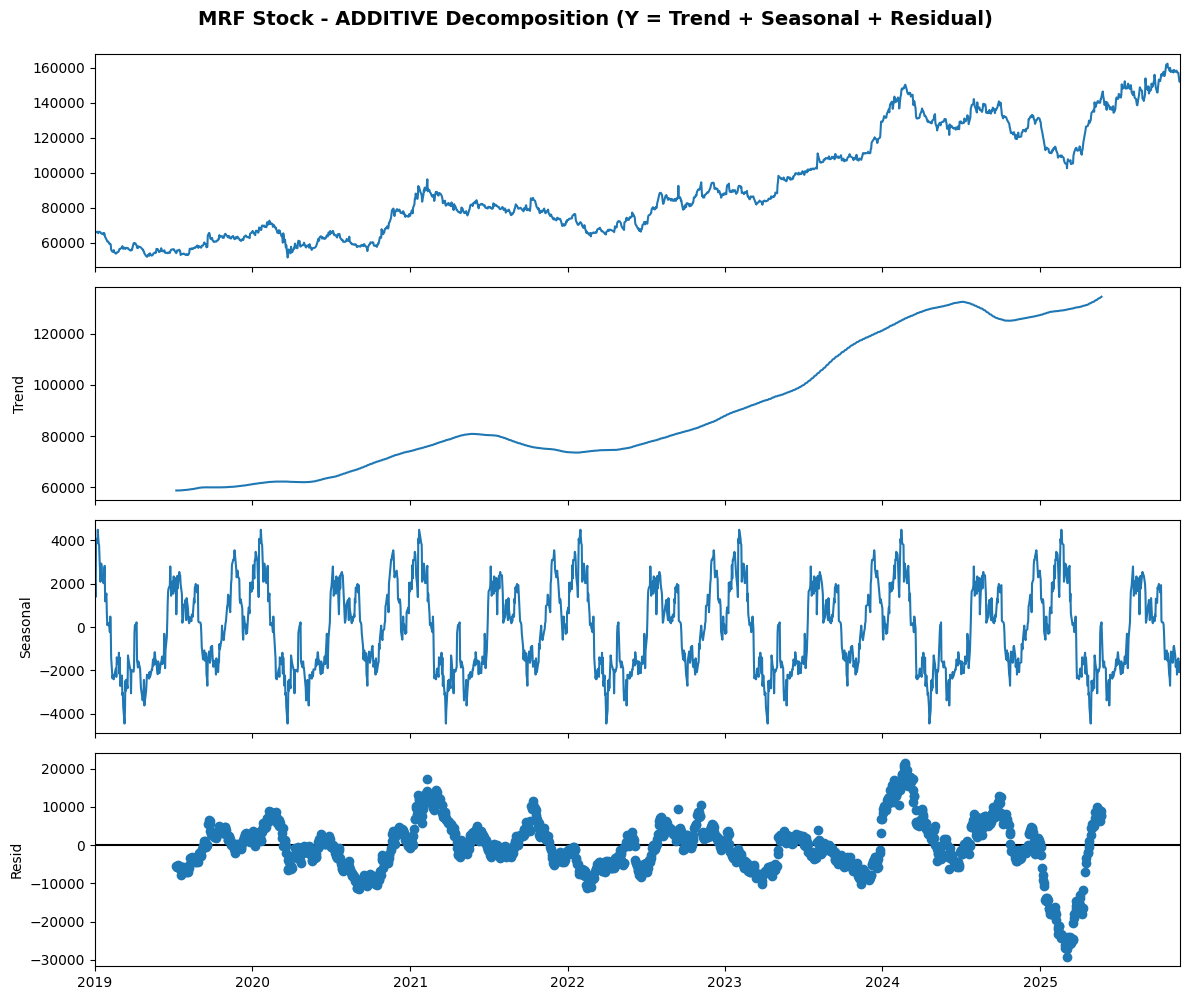


✓ Additive Model: Best when seasonal fluctuations stay constant


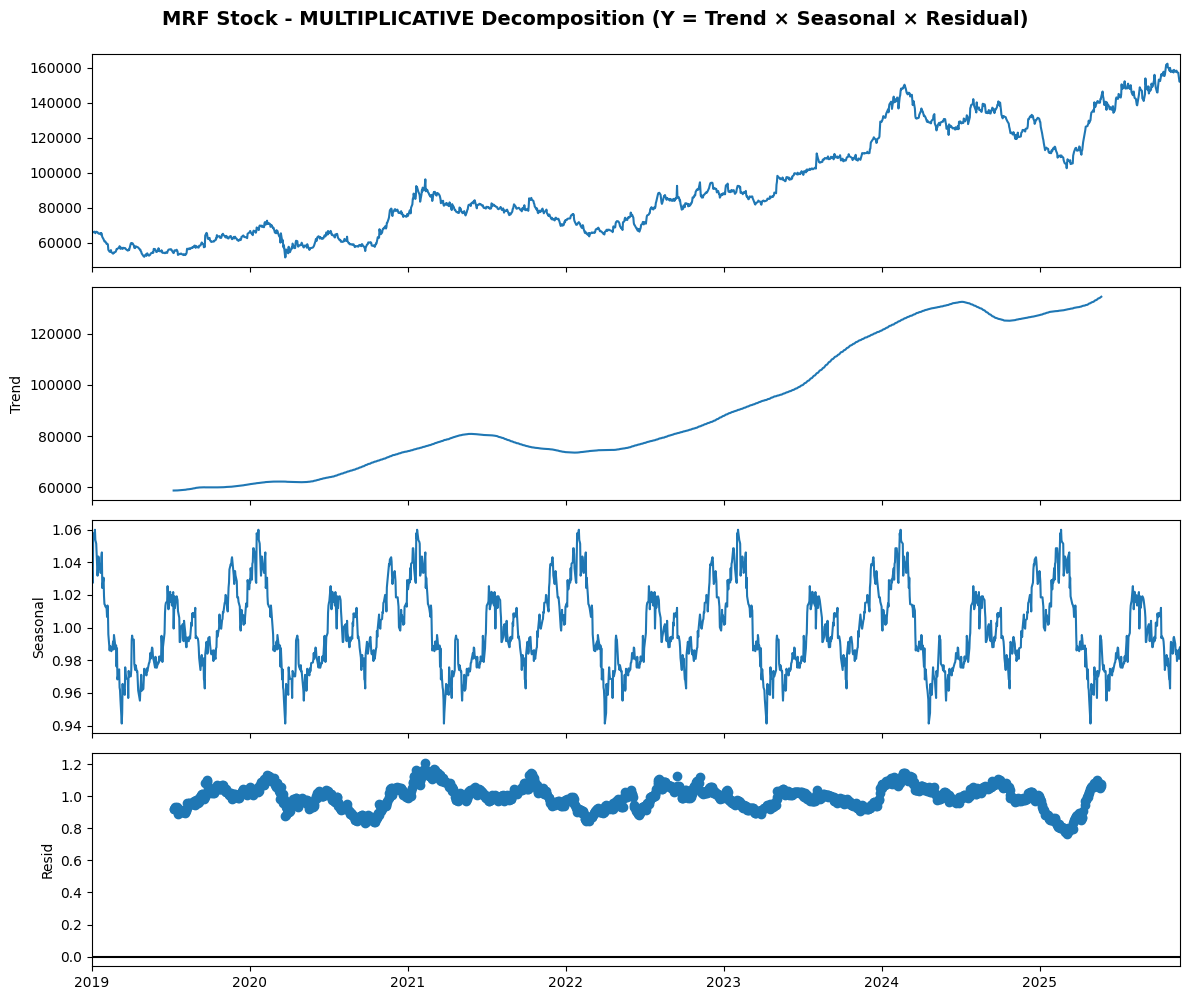

✓ Multiplicative Model: Best when seasonal fluctuations grow with trend

🎯 Analysis Complete! Compare both models to see which fits better.


In [7]:
# ============================================================================
# CLASSICAL TIME SERIES DECOMPOSITION - MRF STOCK
# ============================================================================

# Extract closing prices from MRF data
mrf_close = mrf_data['Close'].dropna()  # Remove any missing values

print("📊 TIME SERIES DECOMPOSITION ANALYSIS")
print("=" * 70)
print("\n🔍 What is Time Series Decomposition?")
print("Breaking down a time series into 3 components:")
print("  • TREND: Long-term direction (upward/downward movement)")
print("  • SEASONAL: Repeating patterns (daily/weekly/yearly cycles)")
print("  • RESIDUAL: Random noise (unpredictable fluctuations)")
print("\n" + "=" * 70)

# ADDITIVE DECOMPOSITION: Y = Trend + Seasonal + Residual
# Use when seasonal variations are roughly constant over time
additive = seasonal_decompose(mrf_close, model='additive', period=252)  # 252 trading days/year

# MULTIPLICATIVE DECOMPOSITION: Y = Trend × Seasonal × Residual
# Use when seasonal variations change proportionally with trend
multiplicative = seasonal_decompose(mrf_close, model='multiplicative', period=252)

# Plot Additive Decomposition
fig1 = additive.plot()
fig1.set_size_inches(12, 10)
fig1.suptitle('MRF Stock - ADDITIVE Decomposition (Y = Trend + Seasonal + Residual)',
              fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ Additive Model: Best when seasonal fluctuations stay constant")

# Plot Multiplicative Decomposition
fig2 = multiplicative.plot()
fig2.set_size_inches(12, 10)
fig2.suptitle('MRF Stock - MULTIPLICATIVE Decomposition (Y = Trend × Seasonal × Residual)',
              fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Multiplicative Model: Best when seasonal fluctuations grow with trend")
print("\n" + "=" * 70)
print("🎯 Analysis Complete! Compare both models to see which fits better.")
print("=" * 70)

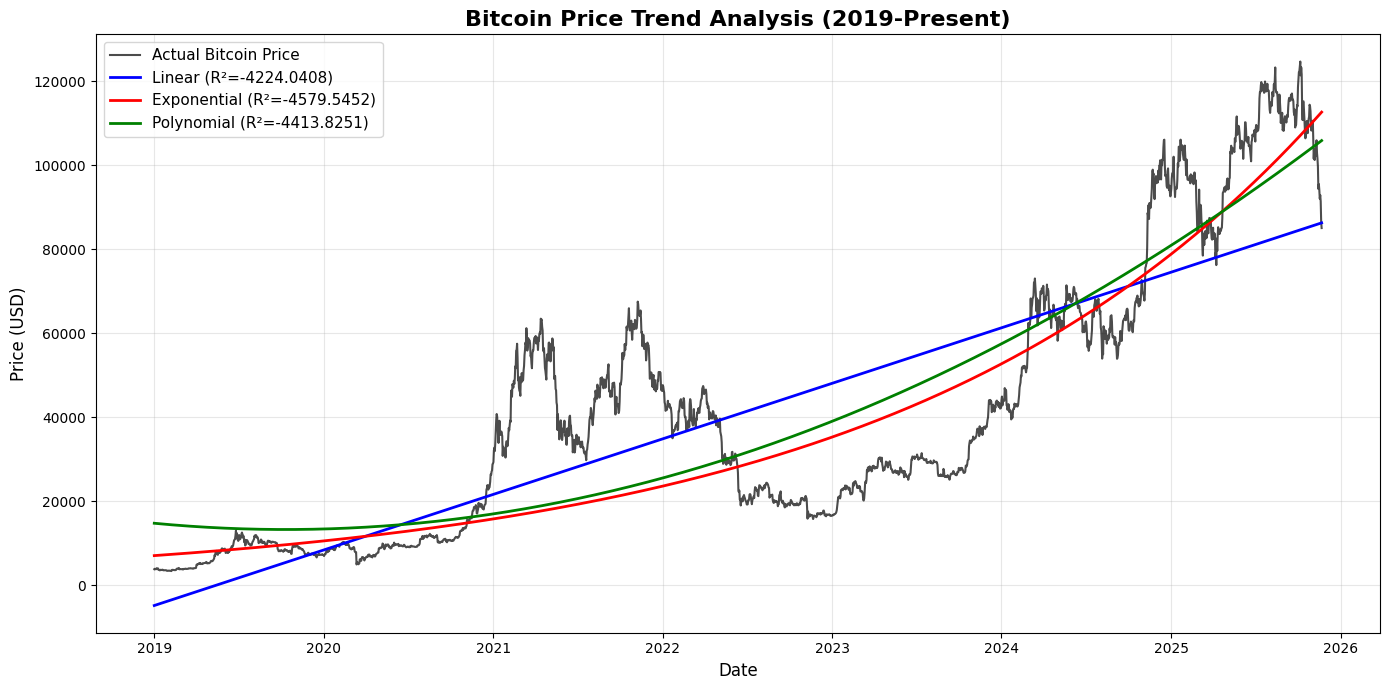


📈 TREND ANALYSIS RESULTS

1. Linear Trend       → R² = -4224.0408 (-422404.08% variance explained)
2. Exponential Trend  → R² = -4579.5452 (-457954.52% variance explained)
3. Polynomial Trend   → R² = -4413.8251 (-441382.51% variance explained)

🏆 BEST FIT: Linear Trend (R² = -4224.0408)

💡 Why R² matters:
  • R² closer to 1.0 = Better fit to the data
  • R² = 1.0 means perfect prediction
  • R² = 0.0 means trend explains nothing

📊 Interpretation:
  → Bitcoin shows LINEAR growth (steady rate of change)


In [8]:
# ============================================================================
# BITCOIN TREND ANALYSIS - Linear, Exponential, Polynomial
# ============================================================================

# Prepare Bitcoin closing price data
btc_close = btc_data['Close'].dropna()
x = np.arange(len(btc_close))  # Time index (0, 1, 2, ...)
y = btc_close.values  # Actual Bitcoin prices

# 1. LINEAR TREND: y = mx + b
linear_coef = np.polyfit(x, y, 1)  # Degree 1 polynomial
linear_fit = np.polyval(linear_coef, x)
r2_linear = 1 - (np.sum((y - linear_fit)**2) / np.sum((y - np.mean(y))**2))

# 2. EXPONENTIAL TREND: y = a * e^(bx) → log(y) = log(a) + bx
log_y = np.log(y)  # Take natural log of prices
exp_coef = np.polyfit(x, log_y, 1)  # Fit linear to log(y)
exp_fit = np.exp(np.polyval(exp_coef, x))  # Convert back to exponential
r2_exp = 1 - (np.sum((y - exp_fit)**2) / np.sum((y - np.mean(y))**2))

# 3. POLYNOMIAL TREND (Degree 2): y = ax² + bx + c
poly_coef = np.polyfit(x, y, 2)  # Degree 2 polynomial
poly_fit = np.polyval(poly_coef, x)
r2_poly = 1 - (np.sum((y - poly_fit)**2) / np.sum((y - np.mean(y))**2))

# PLOT ALL TRENDS
plt.figure(figsize=(14, 7))
plt.plot(btc_close.index, y, label='Actual Bitcoin Price', color='black', linewidth=1.5, alpha=0.7)
plt.plot(btc_close.index, linear_fit, label=f'Linear (R²={r2_linear:.4f})', color='blue', linewidth=2)
plt.plot(btc_close.index, exp_fit, label=f'Exponential (R²={r2_exp:.4f})', color='red', linewidth=2)
plt.plot(btc_close.index, poly_fit, label=f'Polynomial (R²={r2_poly:.4f})', color='green', linewidth=2)
plt.title('Bitcoin Price Trend Analysis (2019-Present)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# PRINT RESULTS
print("\n" + "="*70)
print("📈 TREND ANALYSIS RESULTS")
print("="*70)
print(f"\n1. Linear Trend       → R² = {r2_linear:.4f} ({r2_linear*100:.2f}% variance explained)")
print(f"2. Exponential Trend  → R² = {r2_exp:.4f} ({r2_exp*100:.2f}% variance explained)")
print(f"3. Polynomial Trend   → R² = {r2_poly:.4f} ({r2_poly*100:.2f}% variance explained)")

# Determine best fit
best_r2 = max(r2_linear, r2_exp, r2_poly)
best_model = ['Linear', 'Exponential', 'Polynomial'][[r2_linear, r2_exp, r2_poly].index(best_r2)]

print("\n" + "="*70)
print(f"🏆 BEST FIT: {best_model} Trend (R² = {best_r2:.4f})")
print("="*70)
print("\n💡 Why R² matters:")
print("  • R² closer to 1.0 = Better fit to the data")
print("  • R² = 1.0 means perfect prediction")
print("  • R² = 0.0 means trend explains nothing")
print("\n📊 Interpretation:")
if best_model == 'Exponential':
    print("  → Bitcoin shows EXPONENTIAL growth (compound growth pattern)")
elif best_model == 'Polynomial':
    print("  → Bitcoin shows CURVED growth (accelerating/decelerating)")
else:
    print("  → Bitcoin shows LINEAR growth (steady rate of change)")
print("="*70)

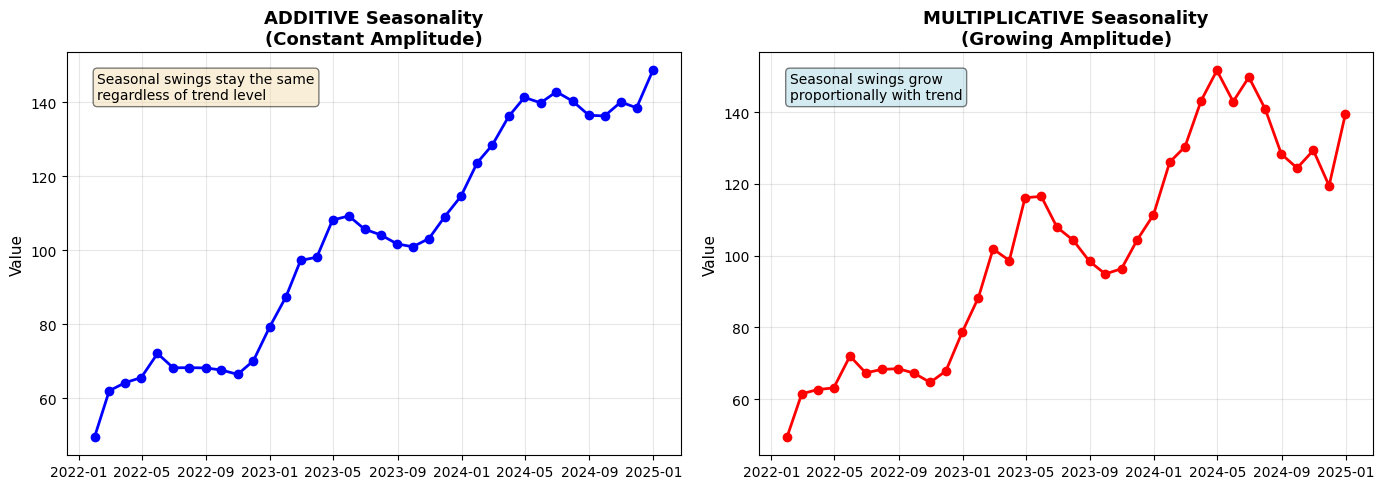

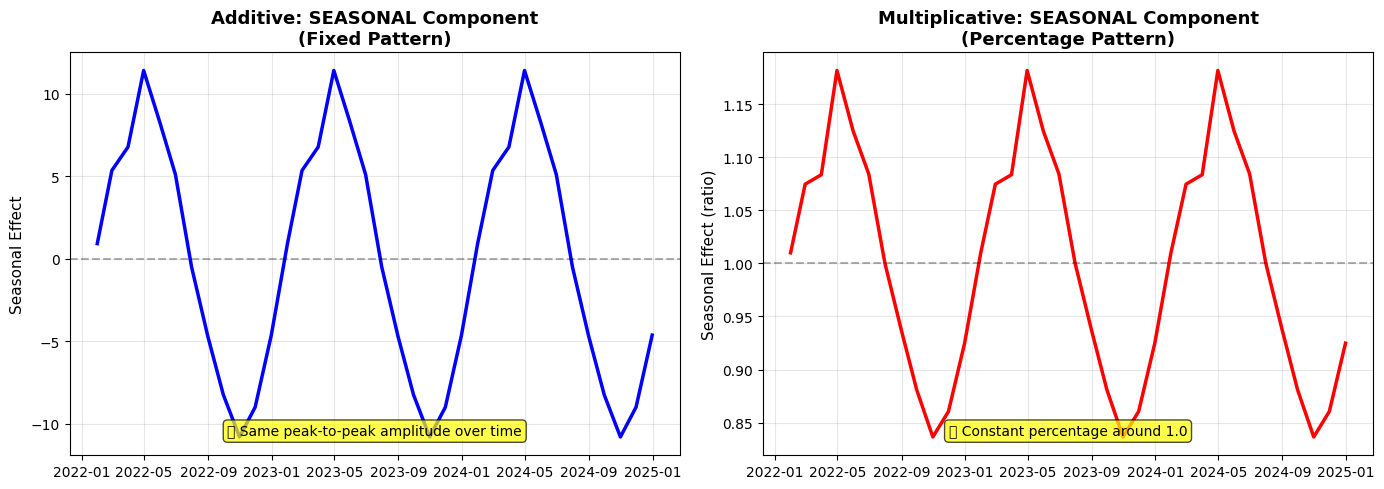


📚 KEY DIFFERENCES

🔵 ADDITIVE (Y = Trend + Seasonal + Residual):
   • Seasonal swings are CONSTANT (e.g., ±10 units every year)
   • Use when: Seasonal pattern doesn't change with trend level
   • Example: Daily temperature variations

🔴 MULTIPLICATIVE (Y = Trend × Seasonal × Residual):
   • Seasonal swings GROW with trend (e.g., ±15% every year)
   • Use when: Seasonal pattern scales with trend level
   • Example: Retail sales (higher base = larger seasonal swings)

💡 TIP: If your data shows growing seasonal fluctuations, use MULTIPLICATIVE!


In [9]:
# ============================================================================
# ADDITIVE vs MULTIPLICATIVE SEASONALITY DEMONSTRATION
# ============================================================================

# Generate time index (3 years of monthly data)
time = np.arange(0, 36)
dates = pd.date_range(start='2022-01-01', periods=36, freq='M')

# Create components
trend = 50 + 3 * time  # Linear upward trend
seasonal = 10 * np.sin(2 * np.pi * time / 12)  # Yearly seasonal pattern (amplitude = 10)
noise = np.random.normal(0, 2, 36)  # Random noise

# 1. ADDITIVE: Y = Trend + Seasonal + Noise (constant seasonal amplitude)
additive_series = trend + seasonal + noise

# 2. MULTIPLICATIVE: Y = Trend × Seasonal × Noise (growing seasonal amplitude)
seasonal_mult = 1 + 0.15 * np.sin(2 * np.pi * time / 12)  # Seasonal as percentage
multiplicative_series = trend * seasonal_mult * (1 + noise/50)

# PLOT ORIGINAL SERIES COMPARISON
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(dates, additive_series, marker='o', linewidth=2, color='blue')
axes[0].set_title('ADDITIVE Seasonality\n(Constant Amplitude)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Value', fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].text(0.05, 0.95, 'Seasonal swings stay the same\nregardless of trend level',
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1].plot(dates, multiplicative_series, marker='o', linewidth=2, color='red')
axes[1].set_title('MULTIPLICATIVE Seasonality\n(Growing Amplitude)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Value', fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].text(0.05, 0.95, 'Seasonal swings grow\nproportionally with trend',
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

# DECOMPOSE AND COMPARE SEASONAL COMPONENTS
add_series = pd.Series(additive_series, index=dates)
mult_series = pd.Series(multiplicative_series, index=dates)

decomp_add = seasonal_decompose(add_series, model='additive', period=12)
decomp_mult = seasonal_decompose(mult_series, model='multiplicative', period=12)

# PLOT SEASONAL COMPONENTS SIDE BY SIDE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(dates, decomp_add.seasonal, linewidth=2.5, color='blue')
axes[0].set_title('Additive: SEASONAL Component\n(Fixed Pattern)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Seasonal Effect', fontsize=11)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[0].grid(alpha=0.3)
axes[0].text(0.5, 0.05, '👉 Same peak-to-peak amplitude over time',
             transform=axes[0].transAxes, fontsize=10, ha='center',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

axes[1].plot(dates, decomp_mult.seasonal, linewidth=2.5, color='red')
axes[1].set_title('Multiplicative: SEASONAL Component\n(Percentage Pattern)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Seasonal Effect (ratio)', fontsize=11)
axes[1].axhline(1, color='black', linestyle='--', alpha=0.3)
axes[1].grid(alpha=0.3)
axes[1].text(0.5, 0.05, '👉 Constant percentage around 1.0',
             transform=axes[1].transAxes, fontsize=10, ha='center',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

# PRINT EXPLANATION
print("\n" + "="*70)
print("📚 KEY DIFFERENCES")
print("="*70)
print("\n🔵 ADDITIVE (Y = Trend + Seasonal + Residual):")
print("   • Seasonal swings are CONSTANT (e.g., ±10 units every year)")
print("   • Use when: Seasonal pattern doesn't change with trend level")
print("   • Example: Daily temperature variations")
print("\n🔴 MULTIPLICATIVE (Y = Trend × Seasonal × Residual):")
print("   • Seasonal swings GROW with trend (e.g., ±15% every year)")
print("   • Use when: Seasonal pattern scales with trend level")
print("   • Example: Retail sales (higher base = larger seasonal swings)")
print("\n" + "="*70)
print("💡 TIP: If your data shows growing seasonal fluctuations, use MULTIPLICATIVE!")
print("="*70)

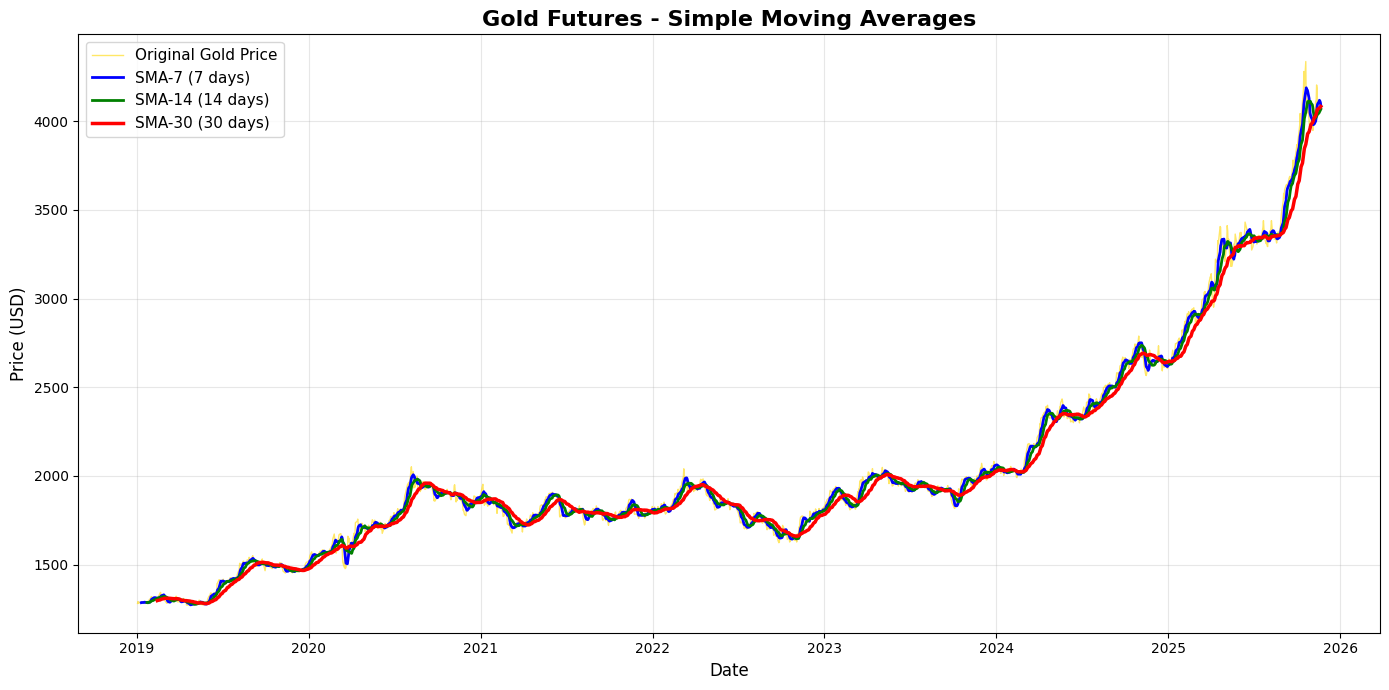


📊 SIMPLE MOVING AVERAGE (SMA) INTERPRETATION

💡 Key Insight: Larger windows = smoother curves but MORE lag

🔵 SMA-7 (Blue):   Fast response, captures short-term trends, more volatile
🟢 SMA-14 (Green): Balanced smoothing, medium-term trend
🔴 SMA-30 (Red):   Very smooth, long-term trend, slow to react

📈 Trading Strategy: When fast SMA crosses above slow SMA = BUY signal!


In [10]:
# ============================================================================
# SIMPLE MOVING AVERAGE (SMA) - Gold Prices
# ============================================================================

# Extract Gold closing prices
gold_close = gold_data['Close'].dropna()

# Calculate SMAs with different window sizes
sma_7 = gold_close.rolling(window=7).mean()    # 1-week average
sma_14 = gold_close.rolling(window=14).mean()  # 2-week average
sma_30 = gold_close.rolling(window=30).mean()  # 1-month average

# Plot original data with all SMAs
plt.figure(figsize=(14, 7))
plt.plot(gold_close.index, gold_close, label='Original Gold Price', color='gold', linewidth=1, alpha=0.6)
plt.plot(sma_7.index, sma_7, label='SMA-7 (7 days)', color='blue', linewidth=2)
plt.plot(sma_14.index, sma_14, label='SMA-14 (14 days)', color='green', linewidth=2)
plt.plot(sma_30.index, sma_30, label='SMA-30 (30 days)', color='red', linewidth=2.5)
plt.title('Gold Futures - Simple Moving Averages', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print interpretation
print("\n" + "="*70)
print("📊 SIMPLE MOVING AVERAGE (SMA) INTERPRETATION")
print("="*70)
print("\n💡 Key Insight: Larger windows = smoother curves but MORE lag")
print("\n🔵 SMA-7 (Blue):   Fast response, captures short-term trends, more volatile")
print("🟢 SMA-14 (Green): Balanced smoothing, medium-term trend")
print("🔴 SMA-30 (Red):   Very smooth, long-term trend, slow to react")
print("\n📈 Trading Strategy: When fast SMA crosses above slow SMA = BUY signal!")
print("="*70)

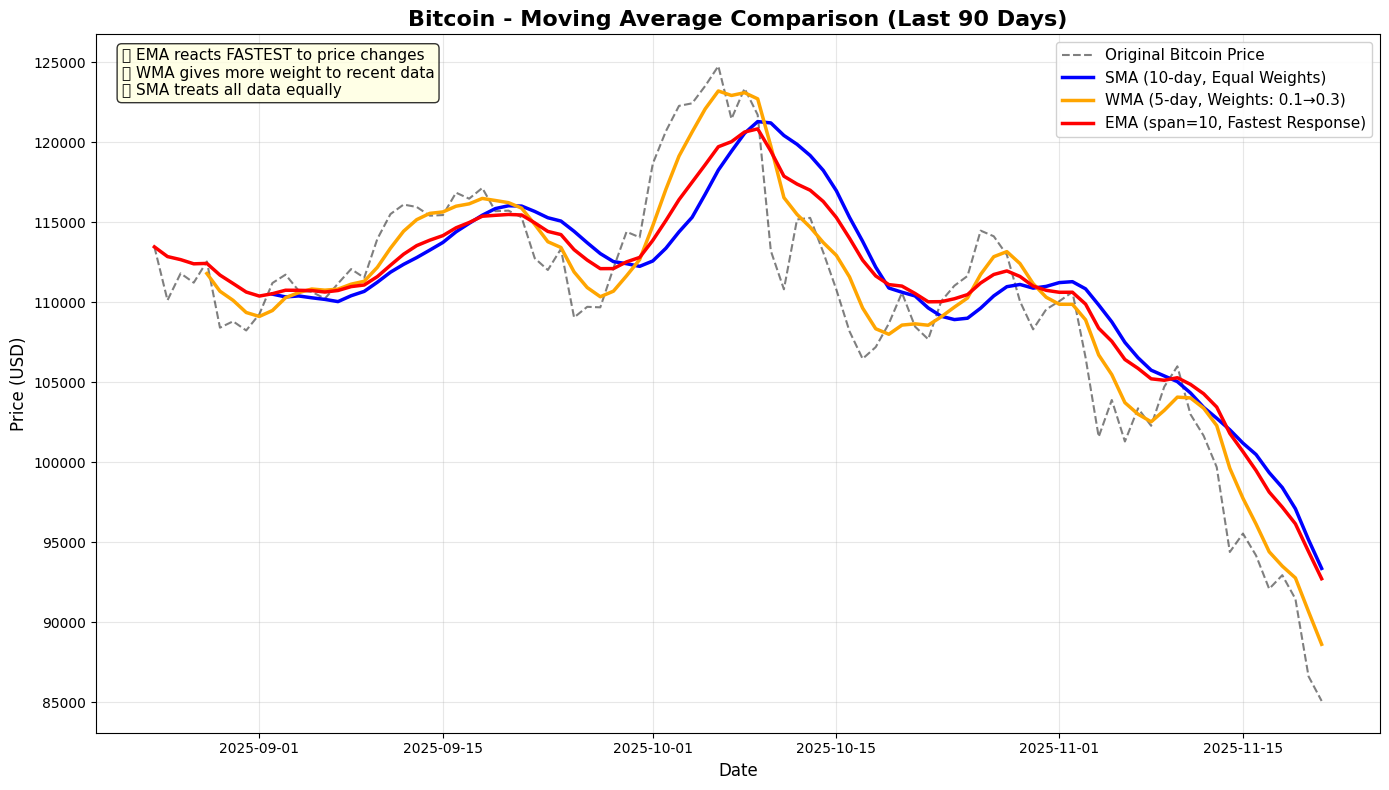


📊 MOVING AVERAGE TYPES - KEY DIFFERENCES

🔵 SMA (Simple):       All days weighted EQUALLY (1/10 each)
🟠 WMA (Weighted):     Recent days get MORE weight (0.3 vs 0.1)
🔴 EMA (Exponential):  Recent days EXPONENTIALLY more important

⚡ Response Speed:  EMA > WMA > SMA
📉 Smoothness:      SMA > WMA > EMA

💡 Look at the chart: EMA hugs the price line closest!


In [11]:
# ============================================================================
# MOVING AVERAGE COMPARISON - SMA vs WMA vs EMA
# ============================================================================

# Get last 90 days of Bitcoin data
btc_close = btc_data['Close'].dropna()
btc_90 = btc_close.iloc[-90:]  # Last 90 days

# 1. Simple Moving Average (SMA) - Equal weights
window = 10
sma = btc_90.rolling(window=window).mean()

# 2. Weighted Moving Average (WMA) - Custom weights favoring recent data
weights = np.array([0.1, 0.15, 0.2, 0.25, 0.3])  # More weight on recent prices
wma = btc_90.rolling(window=5).apply(lambda x: np.dot(x, weights), raw=True)

# 3. Exponential Moving Average (EMA) - Exponentially decreasing weights
ema = btc_90.ewm(span=10, adjust=False).mean()

# PLOT COMPARISON
plt.figure(figsize=(14, 8))
plt.plot(btc_90.index, btc_90, label='Original Bitcoin Price', color='black',
         linewidth=1.5, alpha=0.5, linestyle='--')
plt.plot(sma.index, sma, label='SMA (10-day, Equal Weights)', color='blue', linewidth=2.5)
plt.plot(wma.index, wma, label='WMA (5-day, Weights: 0.1→0.3)', color='orange', linewidth=2.5)
plt.plot(ema.index, ema, label='EMA (span=10, Fastest Response)', color='red', linewidth=2.5)

plt.title('Bitcoin - Moving Average Comparison (Last 90 Days)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='best', fontsize=11, framealpha=0.9)
plt.grid(alpha=0.3)

# Add annotation highlighting EMA's faster response
plt.text(0.02, 0.98, '🔴 EMA reacts FASTEST to price changes\n🟠 WMA gives more weight to recent data\n🔵 SMA treats all data equally',
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

# PRINT EXPLANATION
print("\n" + "="*70)
print("📊 MOVING AVERAGE TYPES - KEY DIFFERENCES")
print("="*70)
print("\n🔵 SMA (Simple):       All days weighted EQUALLY (1/10 each)")
print("🟠 WMA (Weighted):     Recent days get MORE weight (0.3 vs 0.1)")
print("🔴 EMA (Exponential):  Recent days EXPONENTIALLY more important")
print("\n⚡ Response Speed:  EMA > WMA > SMA")
print("📉 Smoothness:      SMA > WMA > EMA")
print("\n💡 Look at the chart: EMA hugs the price line closest!")
print("="*70)

📐 AUTOCORRELATION FORMULA:
   ACF(k) = Corr(Y_t, Y_{t-k})
   → Correlation between current value and value k days ago


✓ Calculated 1703 daily returns
   Mean Return: 0.062%
   Std Dev: 1.598%



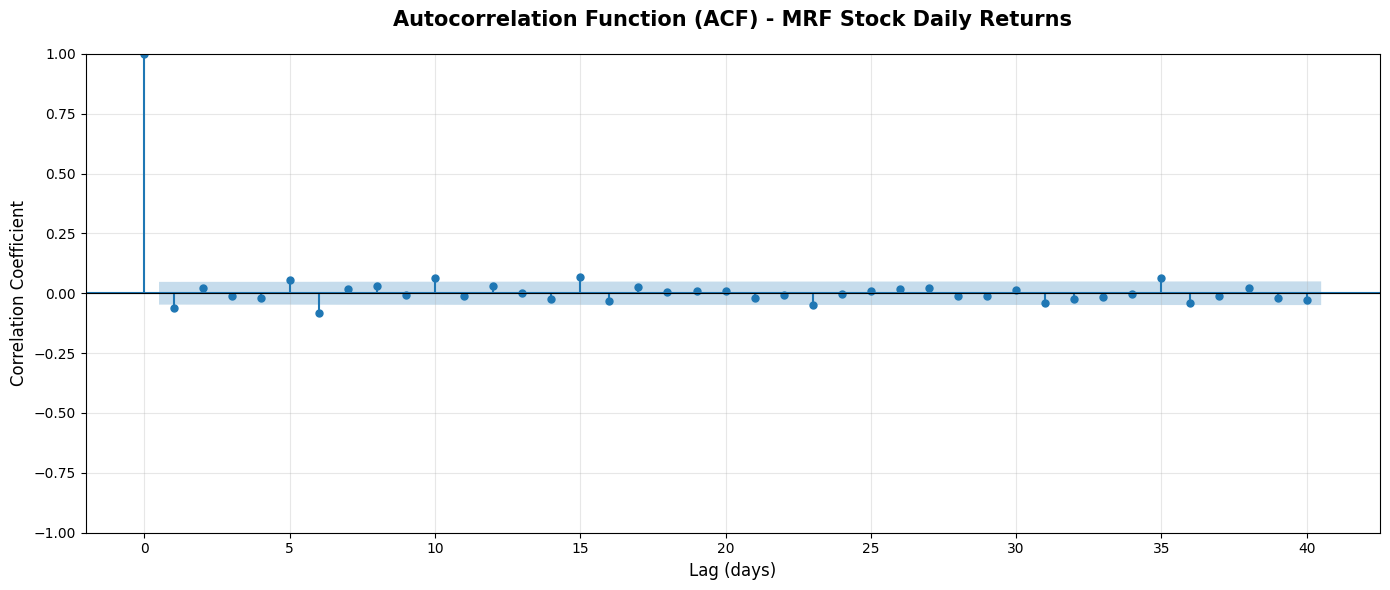


📊 HOW TO INTERPRET ACF

🔵 Blue Shaded Area: 95% confidence interval
   • Bars INSIDE blue zone = NOT significant (random noise)
   • Bars OUTSIDE blue zone = SIGNIFICANT correlation

📈 What it means:
   • High ACF at lag k → Today's return predicts return k days later
   • ACF near 0 → No predictable pattern (random walk)
   • Many significant lags → Strong time dependency

💡 For stock returns: Usually expect ACF ≈ 0 (efficient markets!)


In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# AUTOCORRELATION FUNCTION (ACF) - MRF Stock Returns
# ============================================================================

print("📐 AUTOCORRELATION FORMULA:")
print("   ACF(k) = Corr(Y_t, Y_{t-k})")
print("   → Correlation between current value and value k days ago\n")
print("="*70)

# Calculate daily returns: (Price_today - Price_yesterday) / Price_yesterday
mrf_close = mrf_data['Close'].dropna()
mrf_returns = mrf_close.pct_change().dropna()  # Daily percentage returns

print(f"\n✓ Calculated {len(mrf_returns)} daily returns")
print(f"   Mean Return: {mrf_returns.mean().item()*100:.3f}%")
print(f"   Std Dev: {mrf_returns.std().item()*100:.3f}%\n")

# Plot ACF with confidence intervals (shaded blue area)
fig, ax = plt.subplots(figsize=(14, 6))
plot_acf(mrf_returns, lags=40, ax=ax, alpha=0.05)  # 95% confidence interval
ax.set_title('Autocorrelation Function (ACF) - MRF Stock Daily Returns',
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Lag (days)', fontsize=12)
ax.set_ylabel('Correlation Coefficient', fontsize=12)
ax.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print interpretation
print("\n" + "="*70)
print("📊 HOW TO INTERPRET ACF")
print("="*70)
print("\n🔵 Blue Shaded Area: 95% confidence interval")
print("   • Bars INSIDE blue zone = NOT significant (random noise)")
print("   • Bars OUTSIDE blue zone = SIGNIFICANT correlation")
print("\n📈 What it means:")
print("   • High ACF at lag k → Today's return predicts return k days later")
print("   • ACF near 0 → No predictable pattern (random walk)")
print("   • Many significant lags → Strong time dependency")
print("\n💡 For stock returns: Usually expect ACF ≈ 0 (efficient markets!)")
print("="*70)

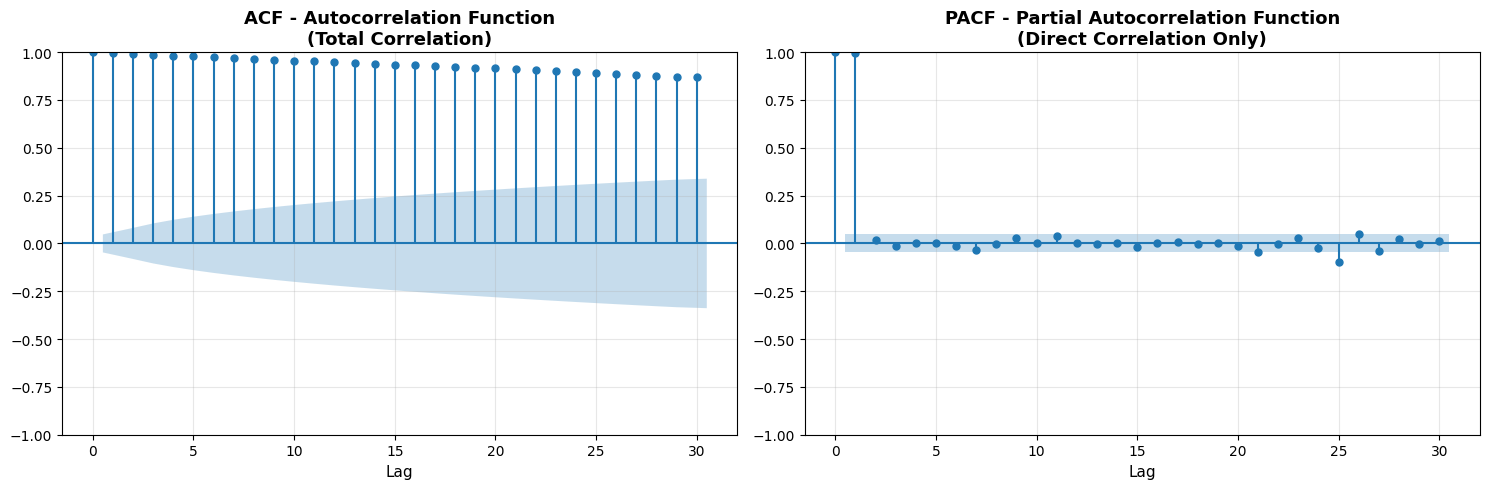


🔍 ACF vs PACF - KEY DIFFERENCE

📊 ACF (Autocorrelation Function):
   → Shows TOTAL correlation between Y_t and Y_{t-k}
   → Includes both direct AND indirect effects
   → Example: Lag 3 includes effects from lag 1 and lag 2

📉 PACF (Partial Autocorrelation Function):
   → Shows DIRECT correlation only (removes intermediate lags)
   → Filters out indirect effects
   → Example: Lag 3 shows ONLY the direct effect, not via lag 1 or 2

💡 Use PACF to identify true lag order for AR models!


In [14]:
# ============================================================================
# ACF vs PACF COMPARISON - Gold Prices
# ============================================================================

# Extract Gold closing prices
gold_close = gold_data['Close'].dropna()

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ACF: Shows TOTAL correlation (includes indirect effects)
plot_acf(gold_close, lags=30, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF - Autocorrelation Function\n(Total Correlation)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Lag', fontsize=11)
axes[0].grid(alpha=0.3)

# PACF: Shows DIRECT correlation (removes indirect effects)
plot_pacf(gold_close, lags=30, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF - Partial Autocorrelation Function\n(Direct Correlation Only)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Lag', fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print explanation
print("\n" + "="*70)
print("🔍 ACF vs PACF - KEY DIFFERENCE")
print("="*70)
print("\n📊 ACF (Autocorrelation Function):")
print("   → Shows TOTAL correlation between Y_t and Y_{t-k}")
print("   → Includes both direct AND indirect effects")
print("   → Example: Lag 3 includes effects from lag 1 and lag 2")
print("\n📉 PACF (Partial Autocorrelation Function):")
print("   → Shows DIRECT correlation only (removes intermediate lags)")
print("   → Filters out indirect effects")
print("   → Example: Lag 3 shows ONLY the direct effect, not via lag 1 or 2")
print("\n💡 Use PACF to identify true lag order for AR models!")
print("="*70)

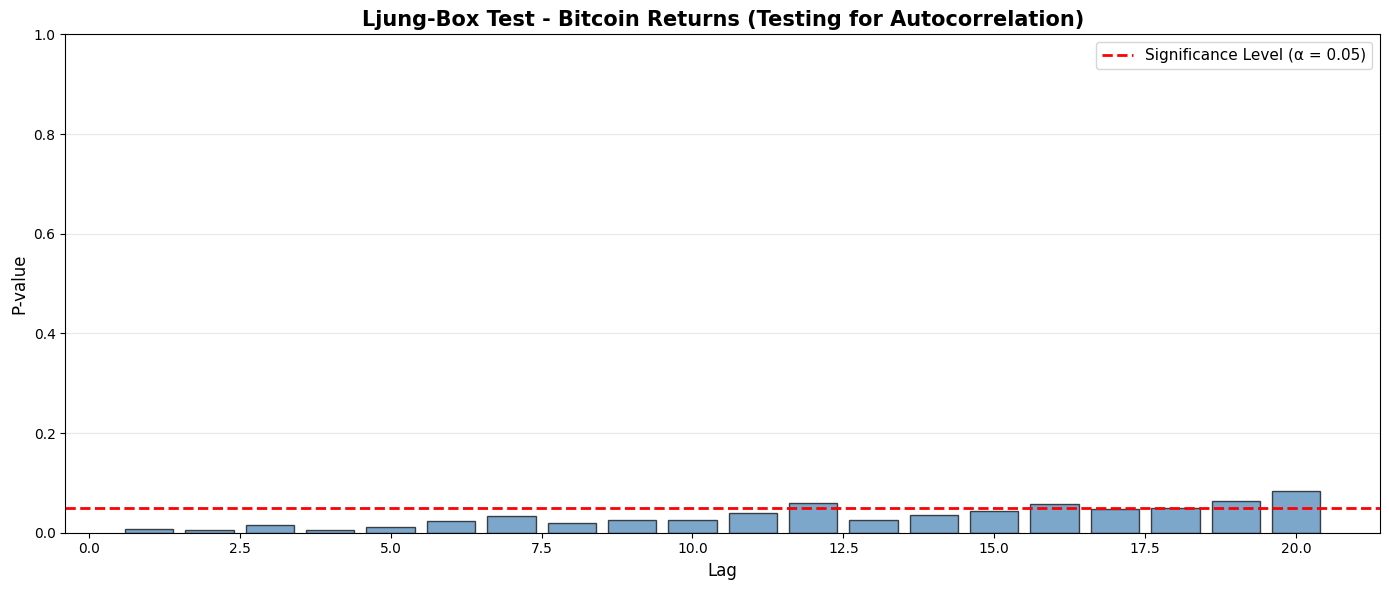


🧪 LJUNG-BOX TEST RESULTS

📊 Hypothesis Testing:
   H₀ (Null): No autocorrelation in the data (returns are random)
   H₁ (Alt):  Autocorrelation exists (returns are predictable)

🔴 Red Line: Significance level (α = 0.05)
   • P-value < 0.05 → REJECT H₀ → Significant autocorrelation detected!
   • P-value > 0.05 → ACCEPT H₀ → No significant autocorrelation

✓ Significant lags found: 16 out of 20
   → Lags with p < 0.05: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 17, 18]
   → Bitcoin returns show autocorrelation (NOT purely random!)



In [15]:
# ============================================================================
# LJUNG-BOX TEST - Testing for Autocorrelation in Bitcoin Returns
# ============================================================================

from statsmodels.stats.diagnostic import acorr_ljungbox

# Calculate Bitcoin daily returns
btc_close = btc_data['Close'].dropna()
btc_returns = btc_close.pct_change().dropna()

# Perform Ljung-Box test for lags 1-20
lb_test = acorr_ljungbox(btc_returns, lags=20, return_df=True)

# Plot p-values
plt.figure(figsize=(14, 6))
plt.bar(lb_test.index, lb_test['lb_pvalue'], color='steelblue', alpha=0.7, edgecolor='black')
plt.axhline(0.05, color='red', linestyle='--', linewidth=2, label='Significance Level (α = 0.05)')
plt.title('Ljung-Box Test - Bitcoin Returns (Testing for Autocorrelation)', fontsize=15, fontweight='bold')
plt.xlabel('Lag', fontsize=12)
plt.ylabel('P-value', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Print interpretation
print("\n" + "="*70)
print("🧪 LJUNG-BOX TEST RESULTS")
print("="*70)
print("\n📊 Hypothesis Testing:")
print("   H₀ (Null): No autocorrelation in the data (returns are random)")
print("   H₁ (Alt):  Autocorrelation exists (returns are predictable)")
print("\n🔴 Red Line: Significance level (α = 0.05)")
print("   • P-value < 0.05 → REJECT H₀ → Significant autocorrelation detected!")
print("   • P-value > 0.05 → ACCEPT H₀ → No significant autocorrelation")

# Count significant lags
sig_lags = lb_test[lb_test['lb_pvalue'] < 0.05]
print(f"\n✓ Significant lags found: {len(sig_lags)} out of 20")
if len(sig_lags) > 0:
    print(f"   → Lags with p < 0.05: {list(sig_lags.index)}")
    print("   → Bitcoin returns show autocorrelation (NOT purely random!)")
else:
    print("   → Bitcoin returns appear random (no autocorrelation)")
print("\n" + "="*70)

📊 STATIONARITY: Constant mean and variance over time



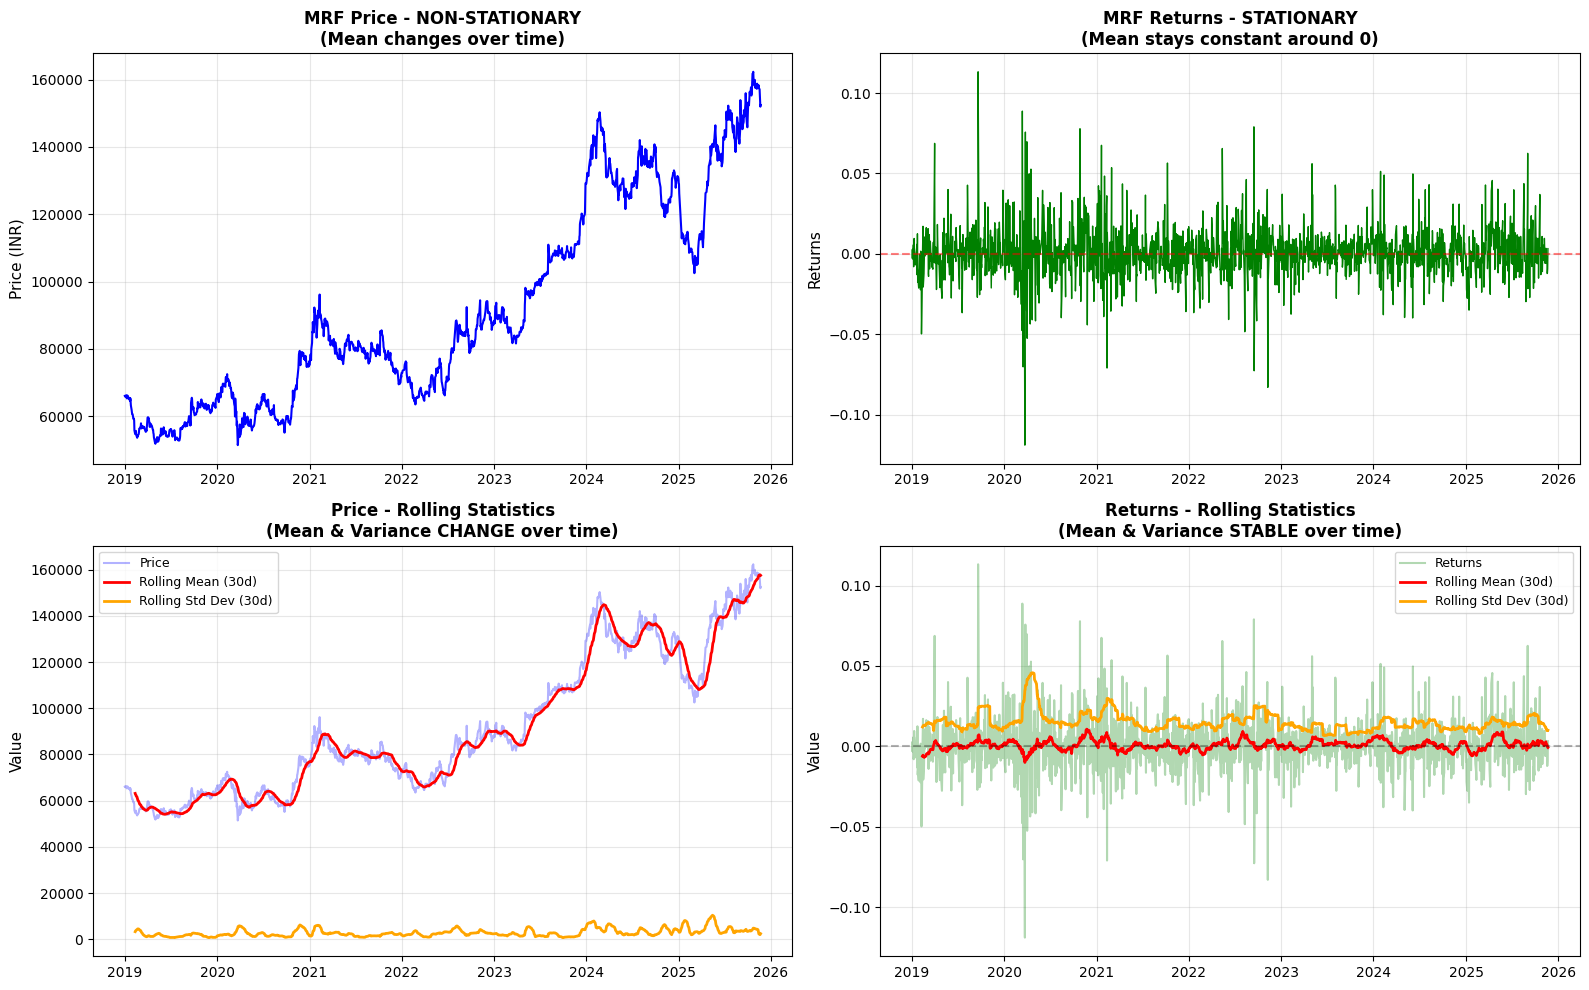


🔍 STATIONARITY DEFINITION

✅ STATIONARY = Constant mean and variance over time
   → Rolling mean stays flat (horizontal line)
   → Rolling std dev stays constant
   → Data oscillates around a fixed level

❌ NON-STATIONARY = Mean/variance changes over time
   → Rolling mean trends up or down
   → Rolling std dev increases/decreases
   → Data shows clear trends or changing volatility

💡 Key Insight: Most time series models require STATIONARY data!
   → Use RETURNS (not prices) for modeling


In [16]:
# ============================================================================
# VISUAL STATIONARITY ASSESSMENT - MRF Stock
# ============================================================================

print("📊 STATIONARITY: Constant mean and variance over time\n")
print("="*70)

# Prepare data
mrf_price = mrf_data['Close'].dropna()
mrf_returns = mrf_price.pct_change().dropna()  # Daily returns

# Calculate rolling statistics (30-day window)
roll_window = 30
price_roll_mean = mrf_price.rolling(window=roll_window).mean()
price_roll_std = mrf_price.rolling(window=roll_window).std()
returns_roll_mean = mrf_returns.rolling(window=roll_window).mean()
returns_roll_std = mrf_returns.rolling(window=roll_window).std()

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Price time series (NON-STATIONARY)
axes[0, 0].plot(mrf_price.index, mrf_price, color='blue', linewidth=1.5)
axes[0, 0].set_title('MRF Price - NON-STATIONARY\n(Mean changes over time)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Price (INR)', fontsize=11)
axes[0, 0].grid(alpha=0.3)

# Plot 2: Returns time series (STATIONARY)
axes[0, 1].plot(mrf_returns.index, mrf_returns, color='green', linewidth=1)
axes[0, 1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].set_title('MRF Returns - STATIONARY\n(Mean stays constant around 0)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Returns', fontsize=11)
axes[0, 1].grid(alpha=0.3)

# Plot 3: Rolling mean & std for PRICE (shows non-stationarity)
axes[1, 0].plot(mrf_price.index, mrf_price, color='blue', alpha=0.3, label='Price')
axes[1, 0].plot(price_roll_mean.index, price_roll_mean, color='red', linewidth=2, label='Rolling Mean (30d)')
axes[1, 0].plot(price_roll_std.index, price_roll_std, color='orange', linewidth=2, label='Rolling Std Dev (30d)')
axes[1, 0].set_title('Price - Rolling Statistics\n(Mean & Variance CHANGE over time)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Value', fontsize=11)
axes[1, 0].legend(loc='best', fontsize=9)
axes[1, 0].grid(alpha=0.3)

# Plot 4: Rolling mean & std for RETURNS (shows stationarity)
axes[1, 1].plot(mrf_returns.index, mrf_returns, color='green', alpha=0.3, label='Returns')
axes[1, 1].plot(returns_roll_mean.index, returns_roll_mean, color='red', linewidth=2, label='Rolling Mean (30d)')
axes[1, 1].plot(returns_roll_std.index, returns_roll_std, color='orange', linewidth=2, label='Rolling Std Dev (30d)')
axes[1, 1].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[1, 1].set_title('Returns - Rolling Statistics\n(Mean & Variance STABLE over time)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Value', fontsize=11)
axes[1, 1].legend(loc='best', fontsize=9)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print interpretation
print("\n" + "="*70)
print("🔍 STATIONARITY DEFINITION")
print("="*70)
print("\n✅ STATIONARY = Constant mean and variance over time")
print("   → Rolling mean stays flat (horizontal line)")
print("   → Rolling std dev stays constant")
print("   → Data oscillates around a fixed level")
print("\n❌ NON-STATIONARY = Mean/variance changes over time")
print("   → Rolling mean trends up or down")
print("   → Rolling std dev increases/decreases")
print("   → Data shows clear trends or changing volatility")
print("\n💡 Key Insight: Most time series models require STATIONARY data!")
print("   → Use RETURNS (not prices) for modeling")
print("="*70)

In [17]:
# ============================================================================
# AUGMENTED DICKEY-FULLER (ADF) TEST - Stationarity Testing
# ============================================================================

from statsmodels.tsa.stattools import adfuller

# Prepare data
mrf_price = mrf_data['Close'].dropna()
mrf_returns = mrf_price.pct_change().dropna()

# Test 1: MRF Price (expect NON-stationary)
adf_price = adfuller(mrf_price, autolag='AIC')

# Test 2: MRF Returns (expect STATIONARY)
adf_returns = adfuller(mrf_returns, autolag='AIC')

# Print results
print("="*70)
print("🧪 AUGMENTED DICKEY-FULLER (ADF) TEST")
print("="*70)
print("\n📋 Hypothesis:")
print("   H₀: Series has unit root (NON-stationary)")
print("   H₁: Series is stationary")
print("   Decision Rule: p-value < 0.05 → Reject H₀ → STATIONARY")

print("\n" + "-"*70)
print("TEST 1: MRF STOCK PRICE")
print("-"*70)
print(f"ADF Statistic:    {adf_price[0]:.6f}")
print(f"P-value:          {adf_price[1]:.6f}")
print(f"Critical Values:")
for key, value in adf_price[4].items():
    print(f"   {key}: {value:.4f}")
print(f"\n🔴 Result: {'STATIONARY' if adf_price[1] < 0.05 else 'NON-STATIONARY (p > 0.05)'}")

print("\n" + "-"*70)
print("TEST 2: MRF STOCK RETURNS")
print("-"*70)
print(f"ADF Statistic:    {adf_returns[0]:.6f}")
print(f"P-value:          {adf_returns[1]:.6f}")
print(f"Critical Values:")
for key, value in adf_returns[4].items():
    print(f"   {key}: {value:.4f}")
print(f"\n🟢 Result: {'STATIONARY (p < 0.05)' if adf_returns[1] < 0.05 else 'NON-STATIONARY'}")

print("\n" + "="*70)
print("💡 INTERPRETATION")
print("="*70)
print("✅ If p < 0.05: REJECT null hypothesis → Series is STATIONARY")
print("❌ If p > 0.05: ACCEPT null hypothesis → Series is NON-STATIONARY")
print("\n📊 ADF Statistic vs Critical Values:")
print("   • ADF < Critical Value → More evidence for stationarity")
print("   • More negative ADF = Stronger stationarity")
print("="*70)

🧪 AUGMENTED DICKEY-FULLER (ADF) TEST

📋 Hypothesis:
   H₀: Series has unit root (NON-stationary)
   H₁: Series is stationary
   Decision Rule: p-value < 0.05 → Reject H₀ → STATIONARY

----------------------------------------------------------------------
TEST 1: MRF STOCK PRICE
----------------------------------------------------------------------
ADF Statistic:    -0.545081
P-value:          0.882915
Critical Values:
   1%: -3.4342
   5%: -2.8633
   10%: -2.5677

🔴 Result: NON-STATIONARY (p > 0.05)

----------------------------------------------------------------------
TEST 2: MRF STOCK RETURNS
----------------------------------------------------------------------
ADF Statistic:    -12.261162
P-value:          0.000000
Critical Values:
   1%: -3.4342
   5%: -2.8632
   10%: -2.5677

🟢 Result: STATIONARY (p < 0.05)

💡 INTERPRETATION
✅ If p < 0.05: REJECT null hypothesis → Series is STATIONARY
❌ If p > 0.05: ACCEPT null hypothesis → Series is NON-STATIONARY

📊 ADF Statistic vs Critical V

In [18]:
# ============================================================================
# ADF vs KPSS TESTS - Complementary Stationarity Tests
# ============================================================================

from statsmodels.tsa.stattools import adfuller, kpss

# Prepare Bitcoin price data
btc_price = btc_data['Close'].dropna()

# Perform ADF test (null = non-stationary)
adf_result = adfuller(btc_price, autolag='AIC')
adf_stat, adf_pval = adf_result[0], adf_result[1]

# Perform KPSS test (null = stationary)
kpss_result = kpss(btc_price, regression='c', nlags='auto')
kpss_stat, kpss_pval = kpss_result[0], kpss_result[1]

# Print results in table format
print("="*70)
print("🧪 STATIONARITY TESTING: ADF vs KPSS (Complementary Tests)")
print("="*70)
print("\n┌─────────────────────────┬──────────────────┬──────────────────┐")
print("│ Test                    │ ADF Test         │ KPSS Test        │")
print("├─────────────────────────┼──────────────────┼──────────────────┤")
print(f"│ Null Hypothesis (H₀)    │ NON-Stationary   │ STATIONARY       │")
print(f"│ Alternative Hyp. (H₁)   │ Stationary       │ NON-Stationary   │")
print("├─────────────────────────┼──────────────────┼──────────────────┤")
print(f"│ Test Statistic          │ {adf_stat:>16.4f} │ {kpss_stat:>16.4f} │")
print(f"│ P-value                 │ {adf_pval:>16.6f} │ {kpss_pval:>16.6f} │")
print("├─────────────────────────┼──────────────────┼──────────────────┤")
print(f"│ Decision (α=0.05)       │ {'Reject H₀':>16} │ {'Reject H₀' if kpss_pval < 0.05 else 'Accept H₀':>16} │")
print(f"│ Conclusion              │ {'Stationary' if adf_pval < 0.05 else 'Non-Stationary':>16} │ {'Non-Stationary' if kpss_pval < 0.05 else 'Stationary':>16} │")
print("└─────────────────────────┴──────────────────┴──────────────────┘")

# Interpretation based on both tests
print("\n" + "="*70)
print("🔍 WHY BOTH TESTS? (Complementary Nature)")
print("="*70)
print("\n🔵 ADF Test:  Assumes NON-stationary as default (conservative)")
print("   → Good at detecting unit roots and trends")
print("   → p < 0.05: Evidence FOR stationarity")
print("\n🟠 KPSS Test: Assumes STATIONARY as default (opposite approach)")
print("   → Good at confirming stationarity")
print("   → p < 0.05: Evidence AGAINST stationarity")

print("\n" + "="*70)
print("📊 INTERPRETATION MATRIX")
print("="*70)
adf_reject = adf_pval < 0.05
kpss_reject = kpss_pval < 0.05

if not adf_reject and kpss_reject:
    conclusion = "✅ Both agree: NON-STATIONARY (needs differencing)"
elif adf_reject and not kpss_reject:
    conclusion = "✅ Both agree: STATIONARY (ready for modeling)"
elif not adf_reject and not kpss_reject:
    conclusion = "⚠️  Inconclusive: Trend-stationary or near unit root"
else:
    conclusion = "⚠️  Conflicting: Further investigation needed"

print(f"\n🎯 Final Conclusion: {conclusion}")
print("\n💡 Best Practice: Use BOTH tests for robust stationarity assessment!")
print("="*70)

🧪 STATIONARITY TESTING: ADF vs KPSS (Complementary Tests)

┌─────────────────────────┬──────────────────┬──────────────────┐
│ Test                    │ ADF Test         │ KPSS Test        │
├─────────────────────────┼──────────────────┼──────────────────┤
│ Null Hypothesis (H₀)    │ NON-Stationary   │ STATIONARY       │
│ Alternative Hyp. (H₁)   │ Stationary       │ NON-Stationary   │
├─────────────────────────┼──────────────────┼──────────────────┤
│ Test Statistic          │          -1.0017 │           5.4798 │
│ P-value                 │         0.752651 │         0.010000 │
├─────────────────────────┼──────────────────┼──────────────────┤
│ Decision (α=0.05)       │        Reject H₀ │        Reject H₀ │
│ Conclusion              │   Non-Stationary │   Non-Stationary │
└─────────────────────────┴──────────────────┴──────────────────┘

🔍 WHY BOTH TESTS? (Complementary Nature)

🔵 ADF Test:  Assumes NON-stationary as default (conservative)
   → Good at detecting unit roots and trends

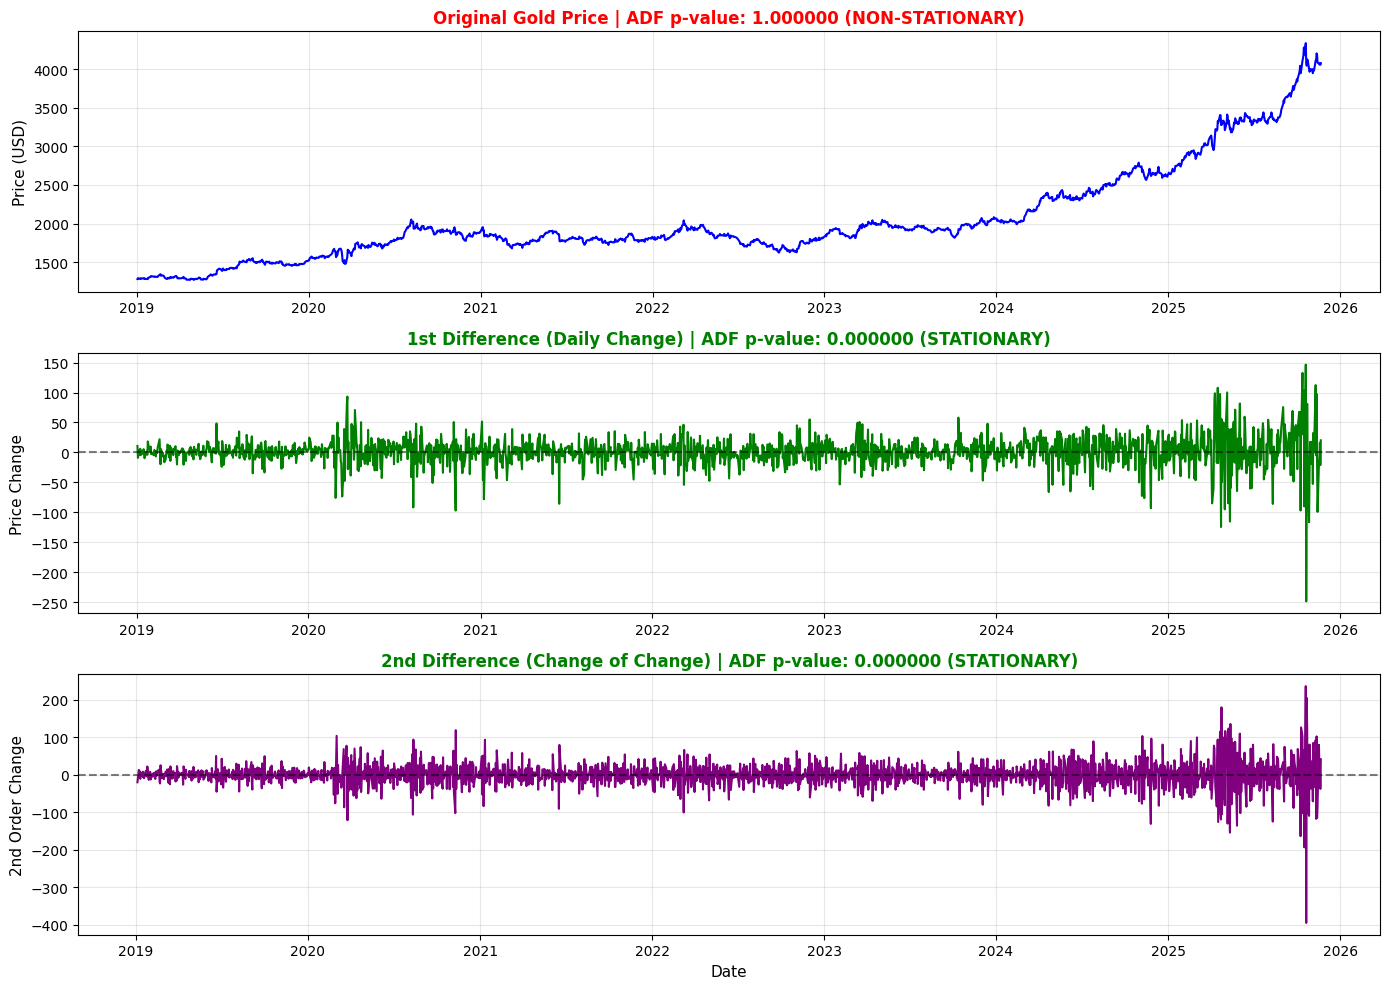


📊 DIFFERENCING RESULTS - ADF Test Summary

Original Series:    p-value = 1.000000  ❌ NON-STATIONARY
1st Difference:     p-value = 0.000000  ✅ STATIONARY
2nd Difference:     p-value = 0.000000  ✅ STATIONARY

🎯 ORDER OF INTEGRATION

📐 Order of Integration: 1
📋 Interpretation: I(1) - Integrated of order 1, needs 1 difference

💡 KEY CONCEPT: Order of integration = number of differences needed for stationarity
   • I(0): Stationary series (no differencing)
   • I(1): First difference is stationary (most common for prices)
   • I(2): Second difference is stationary (rare, over-differencing)


In [19]:
# ============================================================================
# DIFFERENCING - Achieving Stationarity Through Transformation
# ============================================================================

from statsmodels.tsa.stattools import adfuller

# Prepare Gold price data
gold_price = gold_data['Close'].dropna()

# Apply differencing
gold_diff1 = gold_price.diff().dropna()        # 1st difference: Y_t - Y_{t-1}
gold_diff2 = gold_diff1.diff().dropna()        # 2nd difference: diff of diff

# Run ADF test on each series
adf_original = adfuller(gold_price, autolag='AIC')
adf_diff1 = adfuller(gold_diff1, autolag='AIC')
adf_diff2 = adfuller(gold_diff2, autolag='AIC')

# Plot all three series
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Original series
axes[0].plot(gold_price.index, gold_price, color='blue', linewidth=1.5)
axes[0].set_title(f'Original Gold Price | ADF p-value: {adf_original[1]:.6f} (NON-STATIONARY)',
                  fontsize=12, fontweight='bold', color='red' if adf_original[1] > 0.05 else 'green')
axes[0].set_ylabel('Price (USD)', fontsize=11)
axes[0].grid(alpha=0.3)

# 1st difference
axes[1].plot(gold_diff1.index, gold_diff1, color='green', linewidth=1.5)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title(f'1st Difference (Daily Change) | ADF p-value: {adf_diff1[1]:.6f} ({"STATIONARY" if adf_diff1[1] < 0.05 else "NON-STATIONARY"})',
                  fontsize=12, fontweight='bold', color='green' if adf_diff1[1] < 0.05 else 'red')
axes[1].set_ylabel('Price Change', fontsize=11)
axes[1].grid(alpha=0.3)

# 2nd difference
axes[2].plot(gold_diff2.index, gold_diff2, color='purple', linewidth=1.5)
axes[2].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[2].set_title(f'2nd Difference (Change of Change) | ADF p-value: {adf_diff2[1]:.6f} ({"STATIONARY" if adf_diff2[1] < 0.05 else "NON-STATIONARY"})',
                  fontsize=12, fontweight='bold', color='green' if adf_diff2[1] < 0.05 else 'red')
axes[2].set_ylabel('2nd Order Change', fontsize=11)
axes[2].set_xlabel('Date', fontsize=11)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print results
print("\n" + "="*70)
print("📊 DIFFERENCING RESULTS - ADF Test Summary")
print("="*70)
print(f"\nOriginal Series:    p-value = {adf_original[1]:.6f}  {'❌ NON-STATIONARY' if adf_original[1] > 0.05 else '✅ STATIONARY'}")
print(f"1st Difference:     p-value = {adf_diff1[1]:.6f}  {'✅ STATIONARY' if adf_diff1[1] < 0.05 else '❌ NON-STATIONARY'}")
print(f"2nd Difference:     p-value = {adf_diff2[1]:.6f}  {'✅ STATIONARY' if adf_diff2[1] < 0.05 else '❌ NON-STATIONARY'}")

# Determine order of integration
if adf_original[1] < 0.05:
    order = 0
    interpretation = "I(0) - Already stationary, no differencing needed"
elif adf_diff1[1] < 0.05:
    order = 1
    interpretation = "I(1) - Integrated of order 1, needs 1 difference"
else:
    order = 2
    interpretation = "I(2) - Integrated of order 2, needs 2 differences"

print("\n" + "="*70)
print("🎯 ORDER OF INTEGRATION")
print("="*70)
print(f"\n📐 Order of Integration: {order}")
print(f"📋 Interpretation: {interpretation}")
print("\n💡 KEY CONCEPT: Order of integration = number of differences needed for stationarity")
print("   • I(0): Stationary series (no differencing)")
print("   • I(1): First difference is stationary (most common for prices)")
print("   • I(2): Second difference is stationary (rare, over-differencing)")
print("="*70)

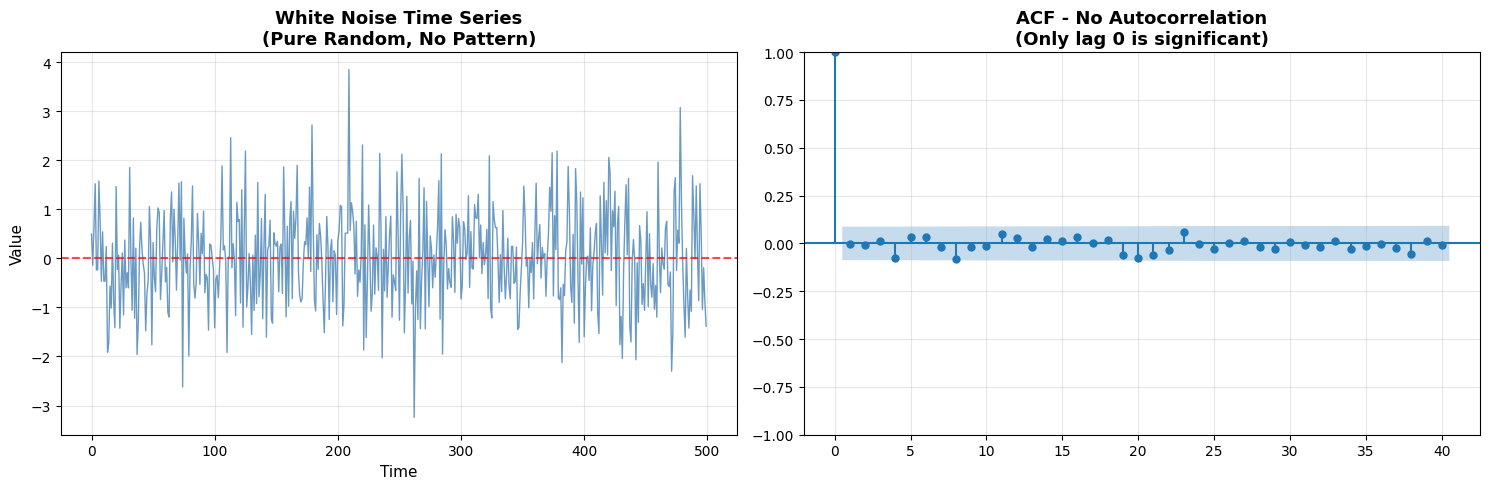


📊 WHITE NOISE PROPERTIES

Mean:              0.006838  (≈ 0)
Variance:          0.960932  (≈ 1)
Std Deviation:     0.980272  (≈ 1)

Rolling Mean Range:  [-0.2999, 0.2392]  (stays near 0)
Rolling Std Range:   [0.7144, 1.1586]  (stays near 1)

✅ WHITE NOISE DEFINITION

🎯 White Noise = No autocorrelation + Constant statistics

   1. Mean is CONSTANT over time (≈ 0)
   2. Variance is CONSTANT over time (≈ 1)
   3. NO autocorrelation (ACF ≈ 0 for all lags except lag 0)
   4. Values are INDEPENDENT (today doesn't predict tomorrow)

💡 Perfect white noise = Unpredictable random series (baseline for models)


In [20]:
# ============================================================================
# WHITE NOISE DEMONSTRATION - Pure Random Process
# ============================================================================

# Generate white noise: mean=0, std=1, 500 observations
np.random.seed(42)  # For reproducibility
white_noise = np.random.normal(0, 1, 500)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Time series
axes[0].plot(white_noise, color='steelblue', linewidth=1, alpha=0.8)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes[0].set_title('White Noise Time Series\n(Pure Random, No Pattern)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Time', fontsize=11)
axes[0].set_ylabel('Value', fontsize=11)
axes[0].grid(alpha=0.3)

# Plot 2: ACF (should show no significant lags except lag 0)
plot_acf(white_noise, lags=40, ax=axes[1], alpha=0.05)
axes[1].set_title('ACF - No Autocorrelation\n(Only lag 0 is significant)', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate statistics over rolling windows to show constancy
roll_mean = pd.Series(white_noise).rolling(window=50).mean()
roll_std = pd.Series(white_noise).rolling(window=50).std()

print("\n" + "="*70)
print("📊 WHITE NOISE PROPERTIES")
print("="*70)
print(f"\nMean:              {np.mean(white_noise):.6f}  (≈ 0)")
print(f"Variance:          {np.var(white_noise):.6f}  (≈ 1)")
print(f"Std Deviation:     {np.std(white_noise):.6f}  (≈ 1)")
print(f"\nRolling Mean Range:  [{roll_mean.min():.4f}, {roll_mean.max():.4f}]  (stays near 0)")
print(f"Rolling Std Range:   [{roll_std.min():.4f}, {roll_std.max():.4f}]  (stays near 1)")

print("\n" + "="*70)
print("✅ WHITE NOISE DEFINITION")
print("="*70)
print("\n🎯 White Noise = No autocorrelation + Constant statistics")
print("\n   1. Mean is CONSTANT over time (≈ 0)")
print("   2. Variance is CONSTANT over time (≈ 1)")
print("   3. NO autocorrelation (ACF ≈ 0 for all lags except lag 0)")
print("   4. Values are INDEPENDENT (today doesn't predict tomorrow)")
print("\n💡 Perfect white noise = Unpredictable random series (baseline for models)")
print("="*70)

📐 AR(1) MODEL EQUATION:
   Y_t = φ * Y_{t-1} + ε_t
   where: φ = 0.7, ε_t ~ N(0, 1) (white noise)



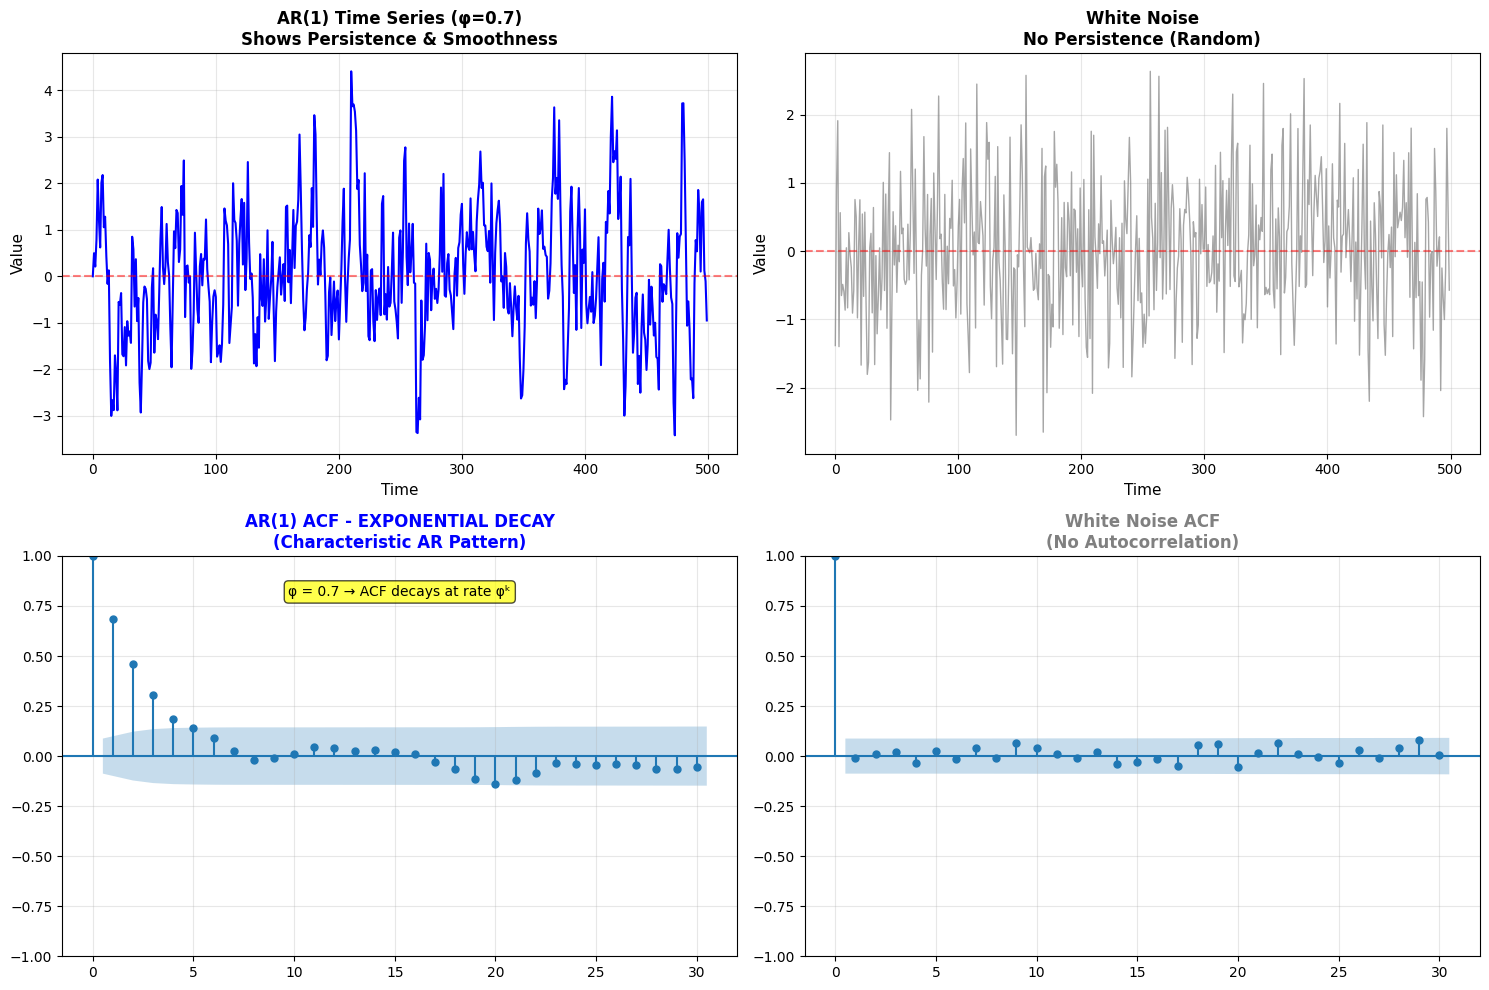


📊 AR(1) CHARACTERISTICS

🔵 AR Coefficient (φ): 0.7
   • |φ| < 1 → Process is STATIONARY
   • Larger |φ| → More persistence (smoother series)
   • Smaller |φ| → Less persistence (more like white noise)

📉 ACF Pattern: EXPONENTIAL DECAY
   • ACF at lag k ≈ φᵏ = 0.7ᵏ
   • Lag 1: 0.7000, Lag 2: 0.4900, Lag 3: 0.3430, ...
   • Decays smoothly to zero (never cuts off sharply)

🔄 AR(1) vs White Noise:
   • AR(1): Shows persistence (values depend on past)
   • White Noise: No persistence (completely random)

💡 Key Insight: AR models create MEMORY in the data!


In [21]:
# ============================================================================
# AR(1) PROCESS SIMULATION - Autoregressive Model
# ============================================================================

print("📐 AR(1) MODEL EQUATION:")
print("   Y_t = φ * Y_{t-1} + ε_t")
print("   where: φ = 0.7, ε_t ~ N(0, 1) (white noise)\n")
print("="*70)

# Simulate AR(1) process: Y_t = 0.7 * Y_{t-1} + ε_t
np.random.seed(42)
n = 500
phi = 0.7  # AR coefficient
ar1_series = np.zeros(n)

for t in range(1, n):
    ar1_series[t] = phi * ar1_series[t-1] + np.random.normal(0, 1)

# Generate white noise for comparison
white_noise = np.random.normal(0, 1, n)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: AR(1) Time Series
axes[0, 0].plot(ar1_series, color='blue', linewidth=1.5)
axes[0, 0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 0].set_title('AR(1) Time Series (φ=0.7)\nShows Persistence & Smoothness', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Time', fontsize=11)
axes[0, 0].set_ylabel('Value', fontsize=11)
axes[0, 0].grid(alpha=0.3)

# Plot 2: White Noise for comparison
axes[0, 1].plot(white_noise, color='gray', linewidth=1, alpha=0.7)
axes[0, 1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].set_title('White Noise\nNo Persistence (Random)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Time', fontsize=11)
axes[0, 1].set_ylabel('Value', fontsize=11)
axes[0, 1].grid(alpha=0.3)

# Plot 3: ACF of AR(1) - Shows EXPONENTIAL DECAY
plot_acf(ar1_series, lags=30, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title('AR(1) ACF - EXPONENTIAL DECAY\n(Characteristic AR Pattern)', fontsize=12, fontweight='bold', color='blue')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].text(0.5, 0.9, f'φ = {phi} → ACF decays at rate φᵏ',
                transform=axes[1, 0].transAxes, fontsize=10, ha='center',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Plot 4: ACF of White Noise - No pattern
plot_acf(white_noise, lags=30, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title('White Noise ACF\n(No Autocorrelation)', fontsize=12, fontweight='bold', color='gray')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print explanation
print("\n" + "="*70)
print("📊 AR(1) CHARACTERISTICS")
print("="*70)
print(f"\n🔵 AR Coefficient (φ): {phi}")
print(f"   • |φ| < 1 → Process is STATIONARY")
print(f"   • Larger |φ| → More persistence (smoother series)")
print(f"   • Smaller |φ| → Less persistence (more like white noise)")
print("\n📉 ACF Pattern: EXPONENTIAL DECAY")
print(f"   • ACF at lag k ≈ φᵏ = {phi}ᵏ")
print(f"   • Lag 1: {phi**1:.4f}, Lag 2: {phi**2:.4f}, Lag 3: {phi**3:.4f}, ...")
print("   • Decays smoothly to zero (never cuts off sharply)")
print("\n🔄 AR(1) vs White Noise:")
print("   • AR(1): Shows persistence (values depend on past)")
print("   • White Noise: No persistence (completely random)")
print("\n💡 Key Insight: AR models create MEMORY in the data!")
print("="*70)

📐 MA(1) MODEL EQUATION:
   Y_t = ε_t + θ * ε_{t-1}
   where: θ = 0.6, ε_t ~ N(0, 1) (white noise)



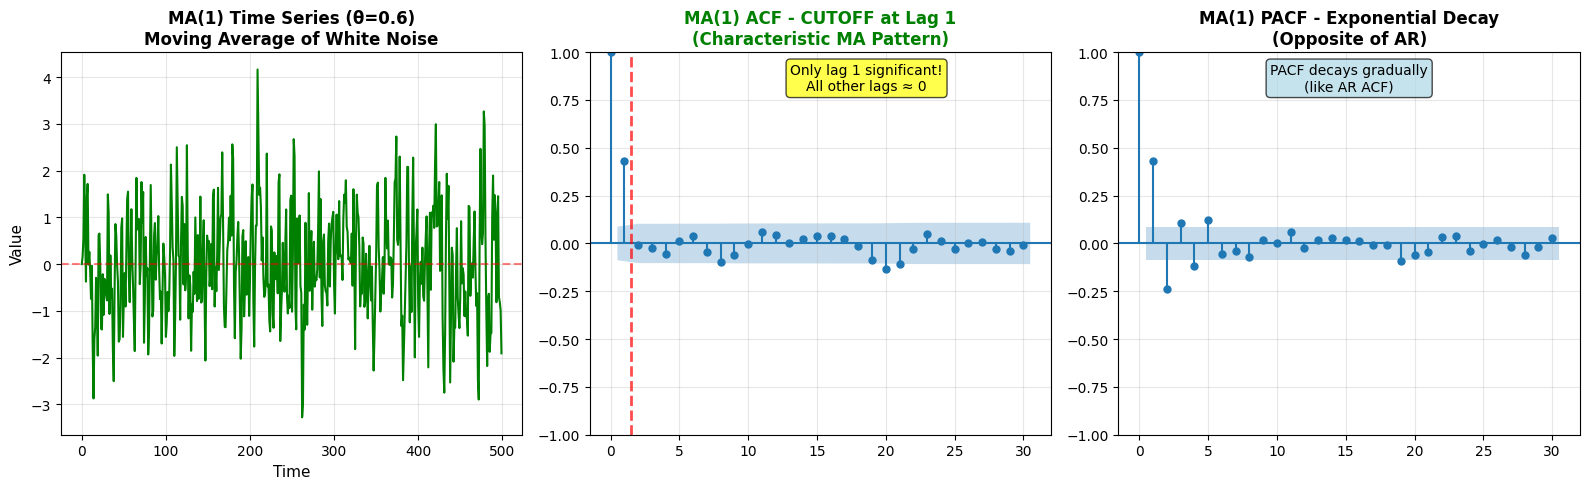


📊 MA(1) CHARACTERISTICS

🟢 MA Coefficient (θ): 0.6
   • |θ| < 1 → Process is INVERTIBLE (can be written as AR(∞))
   • θ controls the strength of moving average effect

📉 KEY PROPERTY - ACF CUTOFF:
   • MA(q) has ACF that CUTS OFF after lag q
   • MA(1) → ACF significant ONLY at lag 1, then zero
   • This is the OPPOSITE of AR (which has exponential decay)

🔄 MA vs AR Patterns:
   ┌─────────┬────────────────────┬────────────────────┐
   │ Model   │ ACF                │ PACF               │
   ├─────────┼────────────────────┼────────────────────┤
   │ AR(p)   │ Decays exponentially│ Cuts off after p   │
   │ MA(q)   │ Cuts off after q    │ Decays exponentially│
   └─────────┴────────────────────┴────────────────────┘

💡 Model Identification: Look at ACF/PACF cutoff patterns!


In [22]:
# ============================================================================
# MA(1) PROCESS SIMULATION - Moving Average Model
# ============================================================================

print("📐 MA(1) MODEL EQUATION:")
print("   Y_t = ε_t + θ * ε_{t-1}")
print("   where: θ = 0.6, ε_t ~ N(0, 1) (white noise)\n")
print("="*70)

# Simulate MA(1) process: Y_t = ε_t + 0.6 * ε_{t-1}
np.random.seed(42)
n = 500
theta = 0.6  # MA coefficient
epsilon = np.random.normal(0, 1, n)  # White noise innovations
ma1_series = np.zeros(n)

for t in range(1, n):
    ma1_series[t] = epsilon[t] + theta * epsilon[t-1]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: MA(1) Time Series
axes[0].plot(ma1_series, color='green', linewidth=1.5)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('MA(1) Time Series (θ=0.6)\nMoving Average of White Noise', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time', fontsize=11)
axes[0].set_ylabel('Value', fontsize=11)
axes[0].grid(alpha=0.3)

# Plot 2: ACF - SHARP CUTOFF after lag 1
plot_acf(ma1_series, lags=30, ax=axes[1], alpha=0.05)
axes[1].set_title('MA(1) ACF - CUTOFF at Lag 1\n(Characteristic MA Pattern)', fontsize=12, fontweight='bold', color='green')
axes[1].grid(alpha=0.3)
axes[1].axvline(1.5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Cutoff Point')
axes[1].text(0.6, 0.9, 'Only lag 1 significant!\nAll other lags ≈ 0',
             transform=axes[1].transAxes, fontsize=10, ha='center',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Plot 3: PACF - DECAYS (opposite of AR)
plot_pacf(ma1_series, lags=30, ax=axes[2], alpha=0.05, method='ywm')
axes[2].set_title('MA(1) PACF - Exponential Decay\n(Opposite of AR)', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3)
axes[2].text(0.5, 0.9, 'PACF decays gradually\n(like AR ACF)',
             transform=axes[2].transAxes, fontsize=10, ha='center',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.show()

# Print explanation
print("\n" + "="*70)
print("📊 MA(1) CHARACTERISTICS")
print("="*70)
print(f"\n🟢 MA Coefficient (θ): {theta}")
print(f"   • |θ| < 1 → Process is INVERTIBLE (can be written as AR(∞))")
print("   • θ controls the strength of moving average effect")
print("\n📉 KEY PROPERTY - ACF CUTOFF:")
print("   • MA(q) has ACF that CUTS OFF after lag q")
print("   • MA(1) → ACF significant ONLY at lag 1, then zero")
print("   • This is the OPPOSITE of AR (which has exponential decay)")
print("\n🔄 MA vs AR Patterns:")
print("   ┌─────────┬────────────────────┬────────────────────┐")
print("   │ Model   │ ACF                │ PACF               │")
print("   ├─────────┼────────────────────┼────────────────────┤")
print("   │ AR(p)   │ Decays exponentially│ Cuts off after p   │")
print("   │ MA(q)   │ Cuts off after q    │ Decays exponentially│")
print("   └─────────┴────────────────────┴────────────────────┘")
print("\n💡 Model Identification: Look at ACF/PACF cutoff patterns!")
print("="*70)

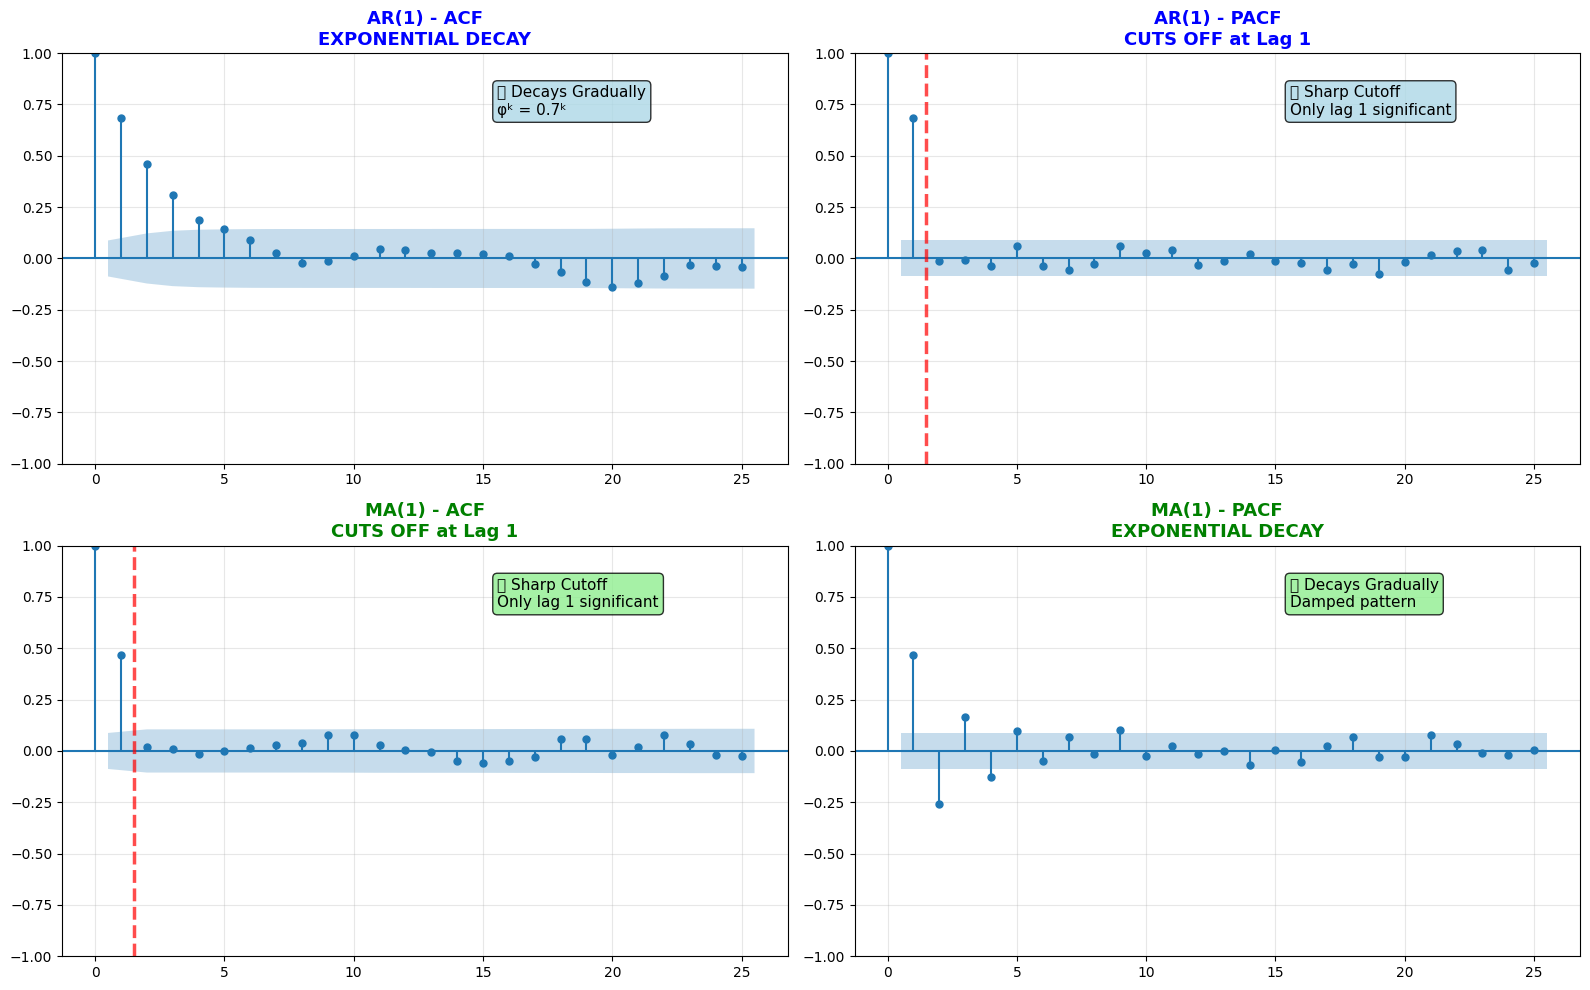


📊 AR vs MA - ACF/PACF PATTERN RECOGNITION GUIDE

┌─────────────┬─────────────────────────┬─────────────────────────┐
│ Process     │ ACF Pattern             │ PACF Pattern            │
├─────────────┼─────────────────────────┼─────────────────────────┤
│ AR(p)       │ Decays exponentially    │ Cuts off after lag p    │
│             │ (gradually fades)       │ (sharp cutoff)          │
├─────────────┼─────────────────────────┼─────────────────────────┤
│ MA(q)       │ Cuts off after lag q    │ Decays exponentially    │
│             │ (sharp cutoff)          │ (gradually fades)       │
├─────────────┼─────────────────────────┼─────────────────────────┤
│ ARMA(p,q)   │ Decays exponentially    │ Decays exponentially    │
│             │ after lag q             │ after lag p             │
└─────────────┴─────────────────────────┴─────────────────────────┘

🎯 MODEL IDENTIFICATION STRATEGY

1️⃣  ACF decays + PACF cuts off  →  AR(p) model
     • Count significant PACF lags to determine p

2

In [23]:
# ============================================================================
# AR(1) vs MA(1) COMPARISON - ACF/PACF Pattern Recognition
# ============================================================================

# Simulate AR(1): Y_t = 0.7 * Y_{t-1} + ε_t
np.random.seed(42)
n = 500
phi = 0.7
ar1_series = np.zeros(n)
for t in range(1, n):
    ar1_series[t] = phi * ar1_series[t-1] + np.random.normal(0, 1)

# Simulate MA(1): Y_t = ε_t + 0.7 * ε_{t-1}
theta = 0.7
epsilon = np.random.normal(0, 1, n)
ma1_series = np.zeros(n)
for t in range(1, n):
    ma1_series[t] = epsilon[t] + theta * epsilon[t-1]

# Create 2x2 subplot comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# AR(1) ACF - Exponential Decay
plot_acf(ar1_series, lags=25, ax=axes[0, 0], alpha=0.05)
axes[0, 0].set_title('AR(1) - ACF\nEXPONENTIAL DECAY', fontsize=13, fontweight='bold', color='blue')
axes[0, 0].text(0.6, 0.85, '🔵 Decays Gradually\nφᵏ = 0.7ᵏ',
                transform=axes[0, 0].transAxes, fontsize=11,
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
axes[0, 0].grid(alpha=0.3)

# AR(1) PACF - Sharp Cutoff after lag 1
plot_pacf(ar1_series, lags=25, ax=axes[0, 1], alpha=0.05, method='ywm')
axes[0, 1].set_title('AR(1) - PACF\nCUTS OFF at Lag 1', fontsize=13, fontweight='bold', color='blue')
axes[0, 1].axvline(1.5, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
axes[0, 1].text(0.6, 0.85, '🔵 Sharp Cutoff\nOnly lag 1 significant',
                transform=axes[0, 1].transAxes, fontsize=11,
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
axes[0, 1].grid(alpha=0.3)

# MA(1) ACF - Sharp Cutoff after lag 1
plot_acf(ma1_series, lags=25, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title('MA(1) - ACF\nCUTS OFF at Lag 1', fontsize=13, fontweight='bold', color='green')
axes[1, 0].axvline(1.5, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
axes[1, 0].text(0.6, 0.85, '🟢 Sharp Cutoff\nOnly lag 1 significant',
                transform=axes[1, 0].transAxes, fontsize=11,
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
axes[1, 0].grid(alpha=0.3)

# MA(1) PACF - Exponential Decay
plot_pacf(ma1_series, lags=25, ax=axes[1, 1], alpha=0.05, method='ywm')
axes[1, 1].set_title('MA(1) - PACF\nEXPONENTIAL DECAY', fontsize=13, fontweight='bold', color='green')
axes[1, 1].text(0.6, 0.85, '🟢 Decays Gradually\nDamped pattern',
                transform=axes[1, 1].transAxes, fontsize=11,
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print comprehensive comparison table
print("\n" + "="*80)
print("📊 AR vs MA - ACF/PACF PATTERN RECOGNITION GUIDE")
print("="*80)
print("\n┌─────────────┬─────────────────────────┬─────────────────────────┐")
print("│ Process     │ ACF Pattern             │ PACF Pattern            │")
print("├─────────────┼─────────────────────────┼─────────────────────────┤")
print("│ AR(p)       │ Decays exponentially    │ Cuts off after lag p    │")
print("│             │ (gradually fades)       │ (sharp cutoff)          │")
print("├─────────────┼─────────────────────────┼─────────────────────────┤")
print("│ MA(q)       │ Cuts off after lag q    │ Decays exponentially    │")
print("│             │ (sharp cutoff)          │ (gradually fades)       │")
print("├─────────────┼─────────────────────────┼─────────────────────────┤")
print("│ ARMA(p,q)   │ Decays exponentially    │ Decays exponentially    │")
print("│             │ after lag q             │ after lag p             │")
print("└─────────────┴─────────────────────────┴─────────────────────────┘")

print("\n" + "="*80)
print("🎯 MODEL IDENTIFICATION STRATEGY")
print("="*80)
print("\n1️⃣  ACF decays + PACF cuts off  →  AR(p) model")
print("     • Count significant PACF lags to determine p")
print("\n2️⃣  ACF cuts off + PACF decays  →  MA(q) model")
print("     • Count significant ACF lags to determine q")
print("\n3️⃣  Both ACF and PACF decay     →  ARMA(p,q) model")
print("     • Need more advanced identification (e.g., AIC/BIC)")

print("\n💡 KEY INSIGHT: AR and MA are MIRROR OPPOSITES in ACF/PACF patterns!")
print("="*80)

📐 ARMA(1,1) MODEL EQUATION:
   Y_t = φ*Y_{t-1} + ε_t + θ*ε_{t-1}
   where: φ=0.6 (AR part), θ=0.4 (MA part), ε_t ~ N(0,1)



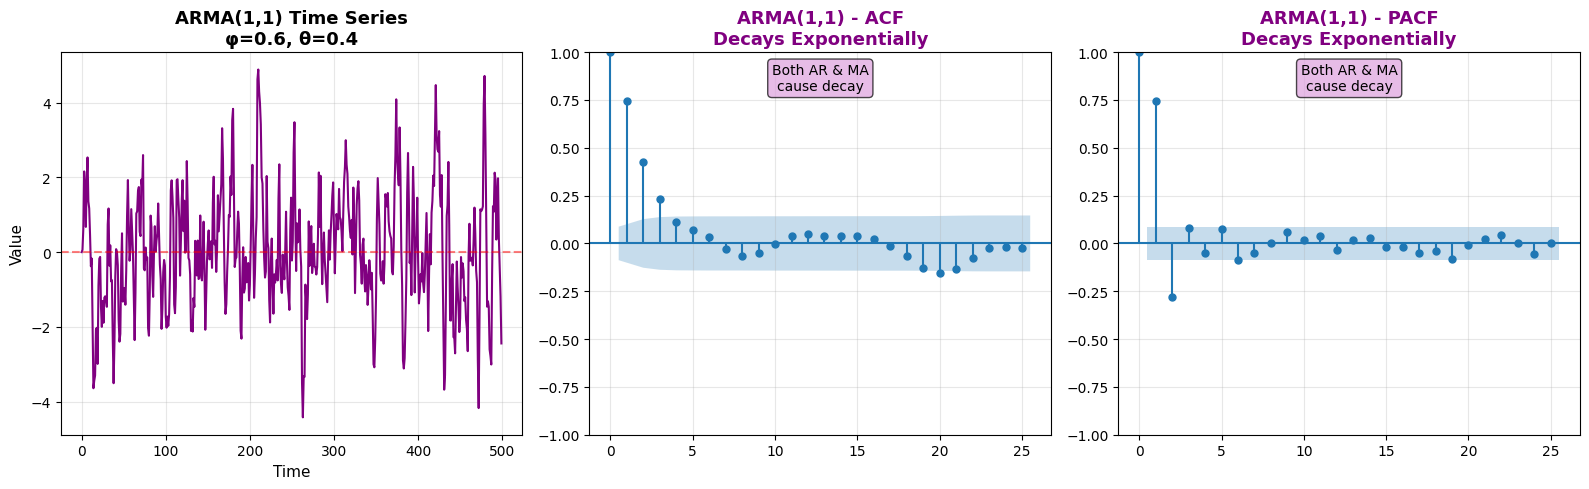


🔄 ARMA COMBINES AR AND MA PROPERTIES

🟣 AR Component (φ=0.6):   Y_t depends on past values
🟣 MA Component (θ=0.4):  Y_t depends on past errors

📊 ACF/PACF Behavior:
   • BOTH ACF and PACF decay exponentially
   • No sharp cutoffs (unlike pure AR or MA)
   • Harder to identify order from plots alone

💡 Key Insight: ARMA models capture complex dynamics!
   → More flexible than pure AR or MA
   → Use AIC/BIC for model selection


In [24]:
# ============================================================================
# ARMA(1,1) PROCESS - Combining AR and MA Components
# ============================================================================

print("📐 ARMA(1,1) MODEL EQUATION:")
print("   Y_t = φ*Y_{t-1} + ε_t + θ*ε_{t-1}")
print("   where: φ=0.6 (AR part), θ=0.4 (MA part), ε_t ~ N(0,1)\n")
print("="*70)

# Simulate ARMA(1,1): Y_t = 0.6*Y_{t-1} + ε_t + 0.4*ε_{t-1}
np.random.seed(42)
n = 500
phi = 0.6   # AR coefficient
theta = 0.4  # MA coefficient
epsilon = np.random.normal(0, 1, n)
arma_series = np.zeros(n)

for t in range(1, n):
    arma_series[t] = phi * arma_series[t-1] + epsilon[t] + theta * epsilon[t-1]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: ARMA(1,1) Time Series
axes[0].plot(arma_series, color='purple', linewidth=1.5)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('ARMA(1,1) Time Series\nφ=0.6, θ=0.4', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Time', fontsize=11)
axes[0].set_ylabel('Value', fontsize=11)
axes[0].grid(alpha=0.3)

# Plot 2: ACF - Exponential decay (both AR and MA influence)
plot_acf(arma_series, lags=25, ax=axes[1], alpha=0.05)
axes[1].set_title('ARMA(1,1) - ACF\nDecays Exponentially', fontsize=13, fontweight='bold', color='purple')
axes[1].grid(alpha=0.3)
axes[1].text(0.5, 0.9, 'Both AR & MA\ncause decay',
             transform=axes[1].transAxes, fontsize=10, ha='center',
             bbox=dict(boxstyle='round', facecolor='plum', alpha=0.7))

# Plot 3: PACF - Exponential decay (both AR and MA influence)
plot_pacf(arma_series, lags=25, ax=axes[2], alpha=0.05, method='ywm')
axes[2].set_title('ARMA(1,1) - PACF\nDecays Exponentially', fontsize=13, fontweight='bold', color='purple')
axes[2].grid(alpha=0.3)
axes[2].text(0.5, 0.9, 'Both AR & MA\ncause decay',
             transform=axes[2].transAxes, fontsize=10, ha='center',
             bbox=dict(boxstyle='round', facecolor='plum', alpha=0.7))

plt.tight_layout()
plt.show()

# Print explanation
print("\n" + "="*70)
print("🔄 ARMA COMBINES AR AND MA PROPERTIES")
print("="*70)
print(f"\n🟣 AR Component (φ={phi}):   Y_t depends on past values")
print(f"🟣 MA Component (θ={theta}):  Y_t depends on past errors")
print("\n📊 ACF/PACF Behavior:")
print("   • BOTH ACF and PACF decay exponentially")
print("   • No sharp cutoffs (unlike pure AR or MA)")
print("   • Harder to identify order from plots alone")
print("\n💡 Key Insight: ARMA models capture complex dynamics!")
print("   → More flexible than pure AR or MA")
print("   → Use AIC/BIC for model selection")
print("="*70)

⚠️  CRITICAL: Never shuffle time series data!
   → Use CHRONOLOGICAL split: Train (past) → Test (future)



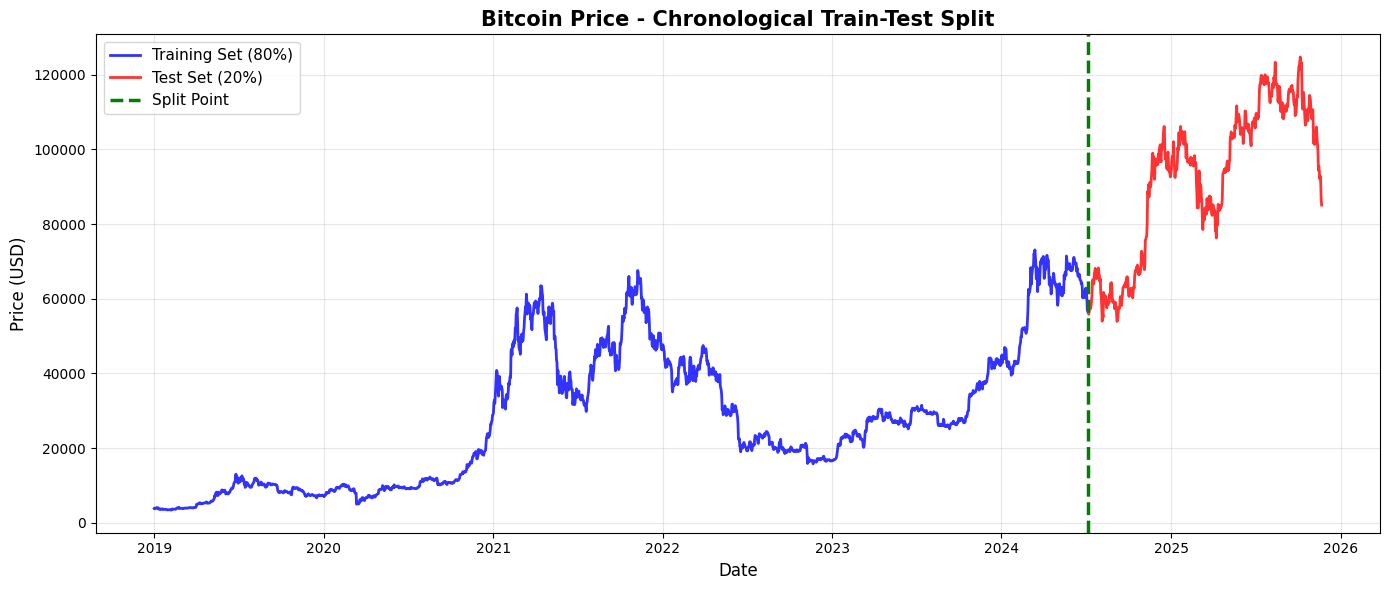


📊 TRAIN-TEST SPLIT SUMMARY

🔵 Training Set:
   • Size: 2013 observations (80.0%)
   • Date Range: 2019-01-01 to 2024-07-05
   • Used for: Model fitting and parameter estimation

🔴 Test Set:
   • Size: 504 observations (20.0%)
   • Date Range: 2024-07-06 to 2025-11-21
   • Used for: Model evaluation (unseen future data)

⚠️  CRITICAL RULES FOR TIME SERIES

❌ DON'T: Shuffle data (breaks temporal order)
❌ DON'T: Use random split (violates causality)
❌ DON'T: Use future data to predict past (data leakage!)

✅ DO: Split chronologically (past → train, future → test)
✅ DO: Train only on past data
✅ DO: Test only on future data

💡 Key: Time flows in ONE direction - respect it!


In [25]:
# ============================================================================
# TIME SERIES TRAIN-TEST SPLIT - Chronological Split Only!
# ============================================================================

print("⚠️  CRITICAL: Never shuffle time series data!")
print("   → Use CHRONOLOGICAL split: Train (past) → Test (future)\n")
print("="*70)

# Prepare Bitcoin closing price data
btc_close = btc_data['Close'].dropna()

# Chronological 80/20 split
split_idx = int(len(btc_close) * 0.8)
train = btc_close.iloc[:split_idx]
test = btc_close.iloc[split_idx:]

# Plot train and test sets
plt.figure(figsize=(14, 6))
plt.plot(train.index, train, color='blue', linewidth=2, label=f'Training Set (80%)', alpha=0.8)
plt.plot(test.index, test, color='red', linewidth=2, label=f'Test Set (20%)', alpha=0.8)
plt.axvline(test.index[0], color='green', linestyle='--', linewidth=2.5, label='Split Point')
plt.title('Bitcoin Price - Chronological Train-Test Split', fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print split information
print("\n" + "="*70)
print("📊 TRAIN-TEST SPLIT SUMMARY")
print("="*70)
print(f"\n🔵 Training Set:")
print(f"   • Size: {len(train)} observations ({len(train)/len(btc_close)*100:.1f}%)")
print(f"   • Date Range: {train.index[0].date()} to {train.index[-1].date()}")
print(f"   • Used for: Model fitting and parameter estimation")
print(f"\n🔴 Test Set:")
print(f"   • Size: {len(test)} observations ({len(test)/len(btc_close)*100:.1f}%)")
print(f"   • Date Range: {test.index[0].date()} to {test.index[-1].date()}")
print(f"   • Used for: Model evaluation (unseen future data)")
print("\n" + "="*70)
print("⚠️  CRITICAL RULES FOR TIME SERIES")
print("="*70)
print("\n❌ DON'T: Shuffle data (breaks temporal order)")
print("❌ DON'T: Use random split (violates causality)")
print("❌ DON'T: Use future data to predict past (data leakage!)")
print("\n✅ DO: Split chronologically (past → train, future → test)")
print("✅ DO: Train only on past data")
print("✅ DO: Test only on future data")
print("\n💡 Key: Time flows in ONE direction - respect it!")
print("="*70)

📊 Data Preparation:
   Original prices: 1736 observations
   Returns (stationary): 1735 observations


📋 AR(2) MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:                   GC=F   No. Observations:                 1735
Model:                 ARIMA(2, 0, 0)   Log Likelihood                5480.447
Date:                Sat, 22 Nov 2025   AIC                         -10952.894
Time:                        08:28:39   BIC                         -10931.059
Sample:                             0   HQIC                        -10944.819
                               - 1735                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.000      2.966      0.003       0.000       0.001
ar.L1 

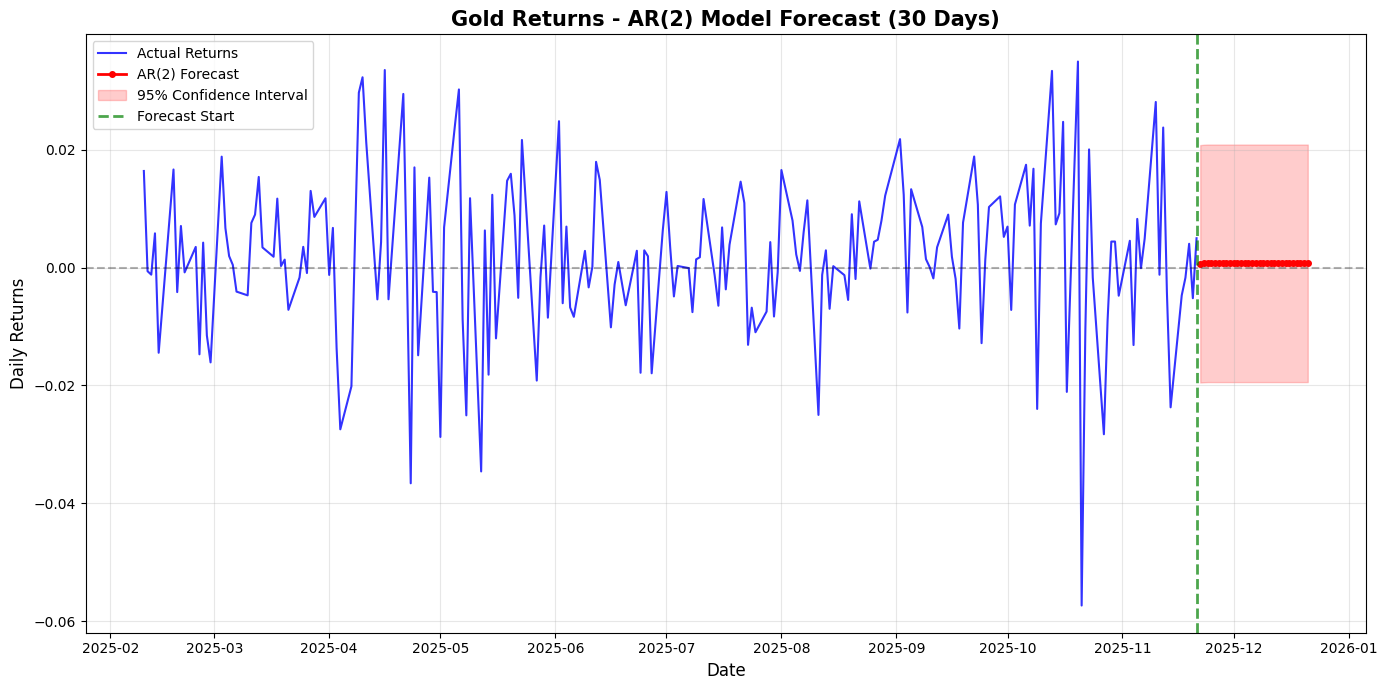


🔮 FORECAST SUMMARY

Forecast Period: 2025-11-22 to 2025-12-21
Mean Forecast Return: 0.0716%
Forecast Std Dev: 0.0015%

💡 Interpretation: AR(2) forecasts tend toward mean (mean reversion)
   Confidence intervals widen as forecast horizon increases


In [26]:
# ============================================================================
# AR(2) MODEL - Fitting and Forecasting Gold Returns
# ============================================================================

from statsmodels.tsa.arima.model import ARIMA

# Step 1: Make data stationary (use returns)
gold_price = gold_data['Close'].dropna()
gold_returns = gold_price.pct_change().dropna()  # Daily returns (stationary)

print("📊 Data Preparation:")
print(f"   Original prices: {len(gold_price)} observations")
print(f"   Returns (stationary): {len(gold_returns)} observations\n")
print("="*70)

# Step 2: Fit AR(2) model - ARIMA(2,0,0)
# order=(p,d,q): p=2 (AR lags), d=0 (no differencing), q=0 (no MA)
ar2_model = ARIMA(gold_returns, order=(2, 0, 0))
ar2_fit = ar2_model.fit()

# Step 3: Print model summary
print("\n📋 AR(2) MODEL SUMMARY")
print("="*70)
print(ar2_fit.summary())
print("\n" + "="*70)
print(f"\n🎯 Key Statistics:")
print(f"   AIC (Akaike Info Criterion): {ar2_fit.aic:.2f} (lower is better)")
print(f"   BIC (Bayesian Info Criterion): {ar2_fit.bic:.2f} (lower is better)")
print(f"\n📐 AR Coefficients:")
print(f"   φ₁ (lag 1): {ar2_fit.params[1]:.6f}")
print(f"   φ₂ (lag 2): {ar2_fit.params[2]:.6f}")
print(f"\n📝 Model Equation:")
print(f"   Y_t = {ar2_fit.params[1]:.4f}*Y_{{t-1}} + {ar2_fit.params[2]:.4f}*Y_{{t-2}} + ε_t")

# Step 4: Forecast next 30 days
forecast_steps = 30
forecast_result = ar2_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int(alpha=0.05)  # 95% confidence interval

# Create forecast dates
last_date = gold_returns.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps, freq='D')

# Step 5: Plot actual vs forecast
plt.figure(figsize=(14, 7))

# Plot last 200 days of actual returns
plt.plot(gold_returns.index[-200:], gold_returns.values[-200:],
         color='blue', linewidth=1.5, label='Actual Returns', alpha=0.8)

# Plot forecast
plt.plot(forecast_dates, forecast_mean, color='red', linewidth=2,
         label='AR(2) Forecast', marker='o', markersize=4)

# Plot confidence interval
plt.fill_between(forecast_dates, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                 color='red', alpha=0.2, label='95% Confidence Interval')

plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.axvline(last_date, color='green', linestyle='--', linewidth=2,
            label='Forecast Start', alpha=0.7)
plt.title('Gold Returns - AR(2) Model Forecast (30 Days)', fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Returns', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("🔮 FORECAST SUMMARY")
print("="*70)
print(f"\nForecast Period: {forecast_dates[0].date()} to {forecast_dates[-1].date()}")
print(f"Mean Forecast Return: {forecast_mean.mean()*100:.4f}%")
print(f"Forecast Std Dev: {forecast_mean.std()*100:.4f}%")
print("\n💡 Interpretation: AR(2) forecasts tend toward mean (mean reversion)")
print("   Confidence intervals widen as forecast horizon increases")
print("="*70)